# ECS assessment

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vtcooper/ecs-assessment/blob/master/ecs_assess.ipynb)

This notebook combines process understanding, the historical record, and paleoclimate evidence to estimate the net radiative feedback from modern CO$_2$ doubling, $\lambda_{\mathrm{2xCO_2}}$, and equilibrium climate sensitivity (ECS).

The inputs and probability model are all in this notebook. Run the cells in order, using either jupyter notebooks or Google Colab.

Using **Jupyter:** first create the environment using conda or mamba,

```bash
conda env create -f ecs.yml
conda activate ecs
```

then open this notebook and select the Python kernel from `ecs`. The environment includes CmdStan and its compiler.

Using **Google Colab:** click the badge above, then start running the notebook in your browser. The first cell detects Colab and installs the extra packages and CmdStan automatically (`ecs.yml` is only needed for Jupyter).

Each chain has a live progress bar. Results, input snapshots, and figures go into `saved_results/` in the working directory. In Colab, download any results you want to keep before the runtime is deleted. Consider deleting unnecessary saved runs to reduce storage.

The short input sections for each line of evidence below are the main places to change assumptions. The probability model can be edited by revising the `stan_code`.

In [1]:
import json
import logging
import os
import sys
from datetime import datetime
from pathlib import Path

## Colab needs a few extra packages; the local ecs environment already has them
try:
    from google.colab import output as colab_output
    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    import shutil
    import subprocess
    import urllib.request

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        "cmdstanpy==1.2.1", "ipywidgets",
    ])
    colab_output.enable_custom_widget_manager()

import cmdstanpy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from IPython.display import Code, HTML, display
from scipy.integrate import trapezoid
from scipy.stats import gaussian_kde, lognorm, norm, skewnorm, truncnorm
from pygments import highlight
from pygments.lexers import get_lexer_by_name
from pygments.formatters import HtmlFormatter
from textwrap import fill


## use the prebuilt Colab bundle, with the same CmdStan version as ecs.yml
if in_colab:
    cmdstan_version = "2.39.0"
    cmdstan_dir = Path.cwd() / f"cmdstan-{cmdstan_version}"
    if not (cmdstan_dir / "bin" / "stanc").exists():
        archive = Path("/tmp") / f"colab-cmdstan-{cmdstan_version}.tar.gz"
        archive_url = (
            "https://github.com/stan-dev/cmdstan/releases/download/"
            f"v{cmdstan_version}/colab-cmdstan-{cmdstan_version}.tgz"
        )
        print("setting up CmdStan for Colab...")
        urllib.request.urlretrieve(archive_url, archive)
        shutil.unpack_archive(str(archive), str(cmdstan_dir.parent))
    cmdstanpy.set_cmdstan_path(str(cmdstan_dir))
    cpp_options = {}
else:
    ## find CmdStan and the compiler supplied by the local environment
    env_bin = Path(sys.executable).resolve().parent
    try:
        cmdstanpy.cmdstan_path()
    except ValueError:
        cmdstanpy.set_cmdstan_path(str(env_bin / "cmdstan"))
    env_cxx = env_bin / "x86_64-conda-linux-gnu-g++"
    cpp_options = {"CXX": str(env_cxx)} if env_cxx.exists() else {}

## plotting settings
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, 
})
print("CmdStanPy", cmdstanpy.__version__, "| CmdStan", cmdstanpy.cmdstan_version())
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

CmdStanPy 1.2.1 | CmdStan (2, 39)


## Global inputs

In [75]:
## save high resolution figures or not
save_figures = False

## forcing is in W m-2; feedbacks are in W m-2 K-1; temperatures are in K
erf_2x, sig_erf_2x = 3.93, 0.29
co2_pi = 284.7  ## ppm

## limit sampling range for uniform lambda prior
lambda_lower, lambda_upper = -100.0, -0.01 

## alternative prior: log(|lambda|) has this mean and standard deviation
lognormal_mu = np.log(2.02815)  ## about 0.707
lognormal_sigma = 1.24420

## sampling setup for 'stan' model below;
## iter_sampling can be increased later for production runs; see below
## keep four chains; run fewer at once if the runtime has fewer CPUs
sampling = dict(
    chains=4, parallel_chains=min(4, os.cpu_count() or 1), iter_warmup=1_000, iter_sampling=5_000,
    adapt_delta=0.95, max_treedepth=12, seed=20250812,
    show_progress=True, show_console=False, refresh=500,  ## live progress for each chain
)

## for calculating likelihoods (does not affect stan model or posterior results)
likelihood_settings = dict(grid_points=500, mc_draws=200_000, seed=20250813)

## store results here
output_dir = Path("saved_results")

## plotting helper
def finish_figure(fig, name):
    fig.tight_layout()
    if save_figures:
        folder = output_dir / "figures"
        folder.mkdir(parents=True, exist_ok=True)
        fig.savefig(folder / f"{name}.pdf", bbox_inches="tight")
    plt.show()

## helpers for adding or multiplying independent variables and their uncertainties
def sum_independent(*terms):
    ## each term is (mean, 1 sigma); independent variances add
    return sum(t[0] for t in terms), np.sqrt(sum(t[1]**2 for t in terms))
    
def product_independent(a, b):
    ## product variance: uncertainty in b, uncertainty in a, and their product
    mu = a[0] * b[0]
    variance = a[0]**2*b[1]**2 + b[0]**2*a[1]**2 + a[1]**2*b[1]**2
    return mu, np.sqrt(variance)

## table display helper
def input_table(rows):
    return pd.DataFrame.from_dict(rows, orient="index", columns=["mean", "1 sigma"])

## Process evidence

Each pair below gives a mean and $1\sigma$. We add the component means and combine their uncertainties in quadrature, assuming independent errors. The cloud values come from the assessed study mixtures; the non-cloud uncertainties are added below without rounding.

To change the cloud assessment by assigning different weights to various studies, use the external cloud_assess notebook. Then enter the changes here.

In [76]:
## cloud feedbacks: high altitude, high amount + optical depth, marine low, land, other
## (mean, 1sigma)
highcloud_alt = (0.24180, 0.125454)
highcloud_amt_optdepth = (0.01350, 0.114829)
marine_lowcloud = (0.30975, 0.211013)
landcloud = (0.08, 0.08)
unassessed_cloud = (0.0, 0.10)
## add the five cloud components; add their independent variances
cloud_total = sum_independent(
    highcloud_alt, highcloud_amt_optdepth, marine_lowcloud,
    landcloud, unassessed_cloud,
)

## non-cloud
## add intermodel, kernel, stratospheric, and extra structural uncertainty in quadrature
planck = (-3.23, np.sqrt(0.04**2 + 0.10**2 + 0 + 0))
## LR+WV mean: tropospheric + stratospheric feedback
lrwv = (1.25 + 0.02, np.sqrt(0.09**2 + 0.08**2 + 0.10**2 + 0.09**2))
surface_albedo = (0.39, np.sqrt(0.09**2 + 0.08**2 + 0. + 0.09**2))
unassessed_noncloud = (0.0, 0.16)
## add Planck, LR+WV, albedo, and other feedbacks, then combine with clouds
noncloud_total = sum_independent(planck, lrwv, surface_albedo, unassessed_noncloud)
process_total = sum_independent(cloud_total, noncloud_total)

process_components = {
    "High cloud: altitude": highcloud_alt,
    "High cloud: amount + tau": highcloud_amt_optdepth,
    "Low cloud: marine": marine_lowcloud,
    "Land cloud": landcloud, "Other cloud": unassessed_cloud,
    "Total cloud": cloud_total, "Planck": planck, "LR + WV": lrwv,
    "Surface albedo": surface_albedo, "Other": unassessed_noncloud,
    "Total feedback": process_total,
}
print(f"Total process feedback: {process_total[0]} ± {process_total[1]} W m-2 K-1")

Total process feedback: -0.9249499999999998 ± 0.4269085282891406 W m-2 K-1


SW20         IPCC AR6         This assessment  \
                          mean 1 sigma     mean 1 sigma            mean   
High cloud: altitude      0.20    0.10     0.22    0.12         0.24180   
High cloud: amount + tau -0.20    0.20    -0.15    0.20         0.01350   
Low cloud: marine         0.37    0.22     0.27    0.20         0.30975   
Land cloud                0.08    0.08     0.08    0.08         0.08000   
Other cloud                NaN     NaN      NaN     NaN         0.00000   
Total cloud               0.45    0.34     0.42    0.33         0.64505   
Planck                   -3.20    0.10    -3.22    0.12        -3.23000   
LR + WV                   1.15    0.18     1.30    0.12         1.27000   
Surface albedo            0.30    0.15     0.35    0.15         0.39000   
Other                     0.00    0.15    -0.01    0.16         0.00000   
Total feedback           -1.30    0.44    -1.16    0.43        -0.92495   
ERF 2xCO2 (W m-2)         4.00    0.30     3.93    0.29         3.93000   

                                    
                           1 sigma  
High cloud: altitude      0.125454  
High cloud: amount + tau  0.114829  
Low cloud: marine         0.211013  
Land cloud                0.080000  
Other cloud               0.100000  
Total cloud               0.299751  
Planck                    0.107703  
LR + WV                   0.180555  
Surface albedo            0.150333  
Other                     0.160000  
Total feedback            0.426909  
ERF 2xCO2 (W m-2)         0.290000

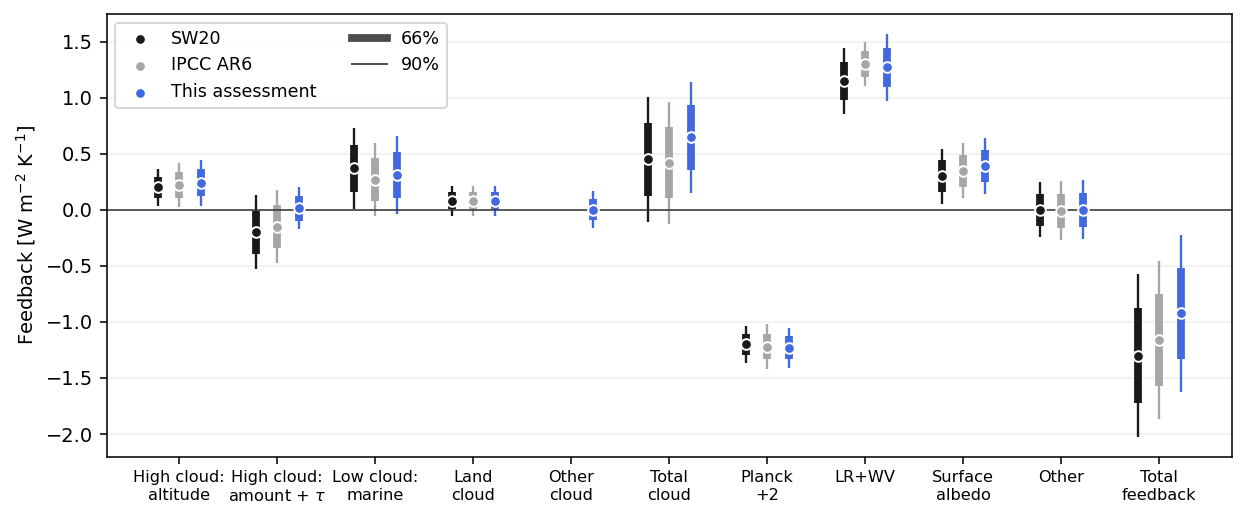

In [77]:
## comparison values from SW20 and AR6; these do not enter the probability model
process_comparisons = {
    "SW20": list(zip(
        [0.20, -0.20, 0.37, 0.08, np.nan, 0.45, -3.20, 1.15, 0.30, 0.00, -1.30],
        [0.10, 0.20, 0.22, 0.08, np.nan, 0.34, 0.10, 0.18, 0.15, 0.15, 0.44])),
    "IPCC AR6": list(zip(
        [0.22, -0.15, 0.27, 0.08, np.nan, 0.42, -3.22, 1.30, 0.35, -0.01, -1.16],
        [0.12, 0.20, 0.20, 0.08, np.nan, 0.33, 0.12, 0.12, 0.15, 0.16, 0.43])),
    "This assessment": list(process_components.values()),
}
process_table = pd.concat({
    name: input_table(dict(zip(process_components, values)))
    for name, values in process_comparisons.items()
}, axis=1)
process_table.loc["ERF 2xCO2 (W m-2)"] = [4.00, 0.30, 3.93, 0.29, erf_2x, sig_erf_2x]
display(process_table)

labels = ["High cloud:\naltitude", "High cloud:\namount + $\\tau$",
          "Low cloud:\nmarine", "Land\ncloud", "Other\ncloud", "Total\ncloud",
          "Planck\n+2", "LR+WV", "Surface\nalbedo", "Other", "Total\nfeedback"]
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = ["0.1", "0.65", "royalblue"]
for offset, color, (name, values) in zip([-0.22, 0, 0.22], colors, process_comparisons.items()):
    means, sigmas = np.array(values).T
    means[6] += 2  ## shift Planck for plotting only
    x = np.arange(len(means)) + offset
    for probability, width in [(0.95, 1.2), (0.83, 4)]:
        halfwidth = norm.ppf(probability) * sigmas
        ax.vlines(x, means-halfwidth, means+halfwidth, color=color, lw=width)
    ax.scatter(x, means, color=color, edgecolor="white", s=30, zorder=3, label=name)
plt.axhline(0, color="0.2", lw=0.8)
ax.set(xticks=np.arange(len(labels)), xticklabels=labels,
       ylabel=r"Feedback [W m$^{-2}$ K$^{-1}$]")
plt.tick_params(axis="x", labelsize='small')
ax.grid(axis="y", alpha=0.2)
handles, names = ax.get_legend_handles_labels()
handles += [Line2D([], [], color="0.3", lw=4), Line2D([], [], color="0.3", lw=1)]
ax.legend(handles, names + ["66%", "90%"], ncol=2, fontsize=9,loc='upper left')
finish_figure(fig, "fig_process_components")

## Historical evidence

The instrumental inputs are 2006–2024 minus 1850–1900 means. 21st-century Trends are for 2006–2024, **per decade**. $\Delta\lambda=\lambda_{\mathrm{2xCO_2}}-\lambda$ accounts for differences between each period's feedback and the feedback from modern CO$_2$ doubling.

The calculations below add the independent uncertainty terms in quadrature, as described in the paper, and retain their full precision.

In [78]:
######################
## instrumental era ##
######################
## T uncertainty: observational + internal variability
T_instrumental = (1.089, np.sqrt(0.08**2 + 0.098**2))
## N mean: 2006–2024 minus preindustrial
## N uncertainty: recent observations + preindustrial + internal variability
N_instrumental = (0.91 - 0.10, np.sqrt(0.14**2 + 0.12**2 + 0.051**2))
f_CO2_instrumental = 1.80 / erf_2x  ## fixed ratio to CO2-doubling forcing
F_aer_instrumental = (-0.24 - 0.73, 0.342)  ## ERFari + ERFaci; spread from paired IGCC members
F_other_instrumental = (1.820, 0.175)

## skew normal: location, scale, shape (these are not the mean and 1 sigma)
## for a normal distribution, set a=0, loc=mean, and scale=1 sigma
## e.g. dict(loc=0.57, scale=0.33, a=0); the input names and Stan code stay the same
dlambda_instrumental = dict(loc=0.976, scale=0.523, a=-3.7573)

#########################
## 21st-century trends ##
#########################
## T uncertainty: observational + internal variability
T_trend = (0.312, np.sqrt(0.016**2 + 0.0694**2))
## N uncertainty: regression standard error + structural uncertainty
N_trend = (0.452, np.sqrt(0.161**2 + 0.10**2))
dlambda_trend = (0.0, 0.30)
f_CO2_trend = 0.329 / erf_2x  ## fixed ratio to CO2-doubling forcing, per decade
F_aer_trend = (0.200, 0.143)  ## IGCC ERFari + ERFaci
F_other_trend = (0.150, 0.016)

#########################

## paired IGCC forcing errors across the two periods
## units: (W m-2) * (W m-2 decade-1); CO2 covariance comes from shared F2x
cov_aerosol = -0.0247083552
cov_other = 0.00108444987

display(pd.Series({
    "aerosol correlation": cov_aerosol / (F_aer_instrumental[1] * F_aer_trend[1]),
    "other forcing correlation": cov_other / (F_other_instrumental[1] * F_other_trend[1]),
    "instrumental dlambda 5th percentile": skewnorm.ppf(.05, **dlambda_instrumental),
    "instrumental dlambda median": skewnorm.median(**dlambda_instrumental),
    "instrumental dlambda 95th percentile": skewnorm.ppf(.95, **dlambda_instrumental),
}, name="value"))

aerosol correlation                    -0.505221
other forcing correlation               0.387304
instrumental dlambda 5th percentile    -0.049061
instrumental dlambda median             0.623480
instrumental dlambda 95th percentile    1.026205
Name: value, dtype: float64

In [79]:
historical_tables = {}
for name, T, N, f_co2, Faer, Fother in [
    ("Instrumental", T_instrumental, N_instrumental, f_CO2_instrumental,
     F_aer_instrumental, F_other_instrumental),
    ("Trend (per decade)", T_trend, N_trend, f_CO2_trend, F_aer_trend, F_other_trend),
]:
    co2_forcing = (f_co2 * erf_2x, abs(f_co2) * sig_erf_2x)
    ## non-CO2 = aerosol + other; total = CO2 + aerosol + other
    ## add the independent variances for each forcing total
    historical_tables[name] = input_table({
        "T": T, "N": N, "f_CO2 (fixed)": (f_co2, 0),
        "dlambda (mean, 1 sigma)": (
            (skewnorm.mean(**dlambda_instrumental), skewnorm.std(**dlambda_instrumental))
            if name == "Instrumental" else dlambda_trend),
        "F_aer": Faer, "F_other": Fother, "F_CO2 (derived)": co2_forcing,
        "F_nonCO2 (derived)": sum_independent(Faer, Fother),
        "F_total (derived)": sum_independent(co2_forcing, Faer, Fother),
    })
display(pd.concat(historical_tables, axis=1))

Instrumental           Trend (per decade)          
                                mean   1 sigma               mean   1 sigma
T                           1.089000  0.126507           0.312000  0.071221
N                           0.810000  0.191314           0.452000  0.189528
f_CO2 (fixed)               0.458015  0.000000           0.083715  0.000000
dlambda (mean, 1 sigma)     0.572744  0.333037           0.000000  0.300000
F_aer                      -0.970000  0.342000           0.200000  0.143000
F_other                     1.820000  0.175000           0.150000  0.016000
F_CO2 (derived)             1.800000  0.132824           0.329000  0.024277
F_nonCO2 (derived)          0.850000  0.384173           0.350000  0.143892
F_total (derived)           2.650000  0.406487           0.679000  0.145926

## Paleo evidence

All anomalies are relative to preindustrial conditions. We use the Last Glacial Maximum (LGM) and the Pliocene's KM5c interglacial. The LGM and Pliocene $\Delta\lambda$ errors have estimated error correlation of 0.5. Other errors are independent apart from the common $F_{\mathrm{2xCO_2}}$.

In [80]:
#########################
########## LGM ##########
#########################
## (mean, 1sigma)
T_LGM = (-6.0, 0.9)
N_LGM = (-0.03, 0.03)
dlambda_LGM = (-0.35, 0.35)
f_CO2_LGM = (-0.55, 0.04) ## ratio of LGM CO2 forcing to 2xCO2

## CH4: SARF times (ERF adjustment + associated ozone and stratospheric water vapor)
## N2O: SARF times its ERF adjustment
## ice sheets: midpoint of two ERF estimates; intermodel variance + 50% extra variance
lgm_forcings = {
    "CH4": (-0.38 * (0.86 + 0.45), 0.05),
    "N2O": (-0.28 * 1.07, 0.10),
    "ice sheets": ((-3.2 - 2.1) / 2, np.sqrt(0.85**2 + 0.5 * 0.85**2)),
    "vegetation": (-0.50, 0.50),
    "aerosols": (-0.50, 1.46),
}
## add CH4, N2O, ice sheets, vegetation, and aerosols; add their independent variances
F_other_LGM = sum_independent(*lgm_forcings.values())
F_CO2_LGM = product_independent(f_CO2_LGM, (erf_2x, sig_erf_2x))
lgm_table = input_table({
    "T (K)": T_LGM, "N (W m-2)": N_LGM,
    "dlambda (W m-2 K-1)": dlambda_LGM, "f_CO2": f_CO2_LGM,
    **{f"F_{k} (W m-2)": v for k, v in lgm_forcings.items()},
    "F_nonCO2 (derived)": F_other_LGM,
    "F_CO2 (derived)": F_CO2_LGM,
    ## total = CO2 + all non-CO2 forcings
    "F_total (derived)": sum_independent(F_CO2_LGM, F_other_LGM),
})
display(lgm_table)

,mean,1 sigma
T (K),-6.0000,0.900000
N (W m-2),-0.0300,0.030000
dlambda (W m-2 K-1),-0.3500,0.350000
f_CO2,-0.5500,0.040000
F_CH4 (W m-2),-0.4978,0.050000
F_N2O (W m-2),-0.2996,0.100000
F_ice sheets (W m-2),-2.6500,1.041033
F_vegetation (W m-2),-0.5000,0.500000
F_aerosols (W m-2),-0.5000,1.460000
F_nonCO2 (derived),-4.4474,1.864899


In [81]:
##############################
########## Pliocene ##########
##############################
## (mean, 1sigma)
T_plio = (3.9, 0.9)
N_plio = (0.0, 0.05)
dlambda_plio = (-0.38, 0.40)

## CO2 uncertainty: proxy error + an equal amount of additional error variance
CO2_plio = (391.0, np.sqrt(15.0**2 + 15.0**2))
f_otherGHG_plio = (0.43, 0.08)  ## other-GHG forcing / CO2 forcing
rho_dlambda_LGM_plio = 0.5

## three AGCM estimates of ERF; assign their range as 1 sigma until more estimates are available
ice_veg_topo = (np.mean([1.26, 1.66, 1.86]), 1.86 - 1.26)
aerosol_plio = (0.10, 0.60)

## non-GHG forcing: ice/vegetation/topography + aerosols; independent variances add
F_plio_nonGHG = (
    ice_veg_topo[0] + aerosol_plio[0],
    np.sqrt(ice_veg_topo[1]**2 + aerosol_plio[1]**2),
)

## concentration-to-forcing relation from Meinshausen et al. (2020),
## with preindustrial N2O = 273 ppb; a common ERF adjustment cancels in the ratio
def co2_sarf(co2_ppm):
    c = np.asarray(co2_ppm, dtype=float)
    a, b, d, ref = -2.4785e-7, 7.5906e-4, 5.2488, 277.15
    alpha = np.where(c <= ref, d, np.where(
        c < ref - b/(2*a), d + a*(c-ref)**2 + b*(c-ref), d - b*b/(4*a)))
    return (alpha - 2.1492e-3*np.sqrt(273.0)) * np.log(c/ref)

def plio_co2_ratio(co2_ppm, pi):
    return (co2_sarf(co2_ppm) - co2_sarf(pi)) / (co2_sarf(2*pi) - co2_sarf(pi))

## Monte Carlo for this summary table; stan samples CO2 directly below
## keep concentrations positive; fixed seed for reproducibility
co2_draws = truncnorm.rvs(
    -CO2_plio[0]/CO2_plio[1], np.inf, loc=CO2_plio[0], scale=CO2_plio[1],
    size=100_000, random_state=np.random.default_rng(20250814),
)
ratios = plio_co2_ratio(co2_draws, co2_pi)
ratio_mu = ratios.mean()
ratio_sd = ratios.std(ddof=1)
F_CO2_plio = product_independent((ratio_mu, ratio_sd), (erf_2x, sig_erf_2x))
F_otherGHG_plio = product_independent(F_CO2_plio, f_otherGHG_plio)
## total GHG = CO2 * (1 + other-GHG ratio); these two forcings are correlated
F_GHG_plio = product_independent(F_CO2_plio, (1+f_otherGHG_plio[0], f_otherGHG_plio[1]))
plio_table = input_table({
    "T (K)": T_plio, "N (W m-2)": N_plio,
    "dlambda (W m-2 K-1)": dlambda_plio, "CO2 (ppm)": CO2_plio,
    "f_otherGHG": f_otherGHG_plio, "F_ice,veg,topo": ice_veg_topo,
    "F_aerosol": aerosol_plio, "F_nonGHG": F_plio_nonGHG,
    "f_CO2 (derived)": (ratio_mu, ratio_sd), "F_CO2 (derived)": F_CO2_plio,
    "F_otherGHG (derived)": F_otherGHG_plio,
    ## total = CO2 + other GHGs + non-GHG forcing
    "F_total (derived)": sum_independent(F_GHG_plio, F_plio_nonGHG),
})
display(plio_table)

,mean,1 sigma
T (K),3.900000,0.900000
N (W m-2),0.000000,0.050000
dlambda (W m-2 K-1),-0.380000,0.400000
CO2 (ppm),391.000000,21.213203
f_otherGHG,0.430000,0.080000
"F_ice,veg,topo",1.593333,0.600000
F_aerosol,0.100000,0.600000
F_nonGHG,1.693333,0.848528
f_CO2 (derived),0.445780,0.078435
F_CO2 (derived),1.751914,0.335032


## Collect inputs in a dictionary

`inputs` is the complete dictionary of input parameters passed to Stan. `mu_` is the mean and `sig_` means $1\sigma$. A switch of 1 includes that line of evidence; 0 leaves it out. Prior choices are `uniform_lambda`, `lognormal_lambda`, and `uniform_ECS`. As described in the paper, `uniform_ECS` is only included for reference; it should not be used as a valid prior.

For a permanent revision to an input parameter listed above, simply change the values above and rerun from there. To run a case with a temporary change to a parameter, pass the changed parameters to `run_case` as shown in an example below, e.g. `run_case("low_pliocene_co2", input_updates={"mu_CO2_plio": 250.0})`. Each run saves its full inputs and leaves the baseline dictionary unchanged.

In [82]:
prior_types = {"uniform_ECS": 0, "uniform_lambda": 1, "lognormal_lambda": 2}
inputs = {
    "erf_2x": erf_2x, "sig_F2xCO2": sig_erf_2x, "CO2_PI": co2_pi,
    "lambda_lower": lambda_lower, "lambda_upper": lambda_upper,
    "lognormal_mu": lognormal_mu, "lognormal_sigma": lognormal_sigma,
    "lambda_prior_type": prior_types["uniform_lambda"],
    "include_process": 1, "include_instrumental": 1, "include_trend": 1,
    "include_lgm": 1, "include_pliocene": 1,
    "mu_lambda": process_total[0], "sig_lambda": process_total[1],
    "f_CO2_instrumental": f_CO2_instrumental, "f_CO2_trend": f_CO2_trend,
    "loc_dlambda_instrumental": dlambda_instrumental["loc"],
    "scale_dlambda_instrumental": dlambda_instrumental["scale"],
    "shape_dlambda_instrumental": dlambda_instrumental["a"],
    "cov_F_anthro_aerosol_instrumental_trend": cov_aerosol,
    "cov_F_other_instrumental_trend": cov_other,
    "rho_dlambda_LGM_plio": rho_dlambda_LGM_plio,
}
## expand each (mean, 1 sigma) pair into two clearly named Stan inputs
for name, (mu, sig) in {
    "T_instrumental": T_instrumental, "N_instrumental": N_instrumental,
    "F_anthro_aerosol_instrumental": F_aer_instrumental,
    "F_other_instrumental": F_other_instrumental,
    "T_trend": T_trend, "N_trend": N_trend, "dlambda_trend": dlambda_trend,
    "F_anthro_aerosol_trend": F_aer_trend, "F_other_trend": F_other_trend,
    "T_LGM": T_LGM, "N_LGM": N_LGM, "dlambda_LGM": dlambda_LGM,
    "f_CO2_LGM": f_CO2_LGM, "F_other_LGM": F_other_LGM,
    "T_plio": T_plio, "N_plio": N_plio, "dlambda_plio": dlambda_plio,
    "CO2_plio": CO2_plio, "f_otherGHG": f_otherGHG_plio,
    "F_plio_nonGHG": F_plio_nonGHG,
}.items():
    inputs[f"mu_{name}"] = float(mu)
    inputs[f"sig_{name}"] = float(sig)

print(f"{len(inputs)} inputs, including the prior and evidence switches")

63 inputs, including the prior and evidence switches


# Probability model

The following code defines the probability model in `stan`. It is only necessary to re-run the `stan` code cell below when the text in that cell has been changed (i.e., the probability model needs to be re-compiled). CmdStan needs a file to compile, so the below cell writes the embedded probability model into the results folder automatically.

The common physical equation that underlies the statistical model is

$$N = F + (\lambda_{\mathrm{2xCO_2}}-\Delta\lambda)T + \epsilon,
\qquad \mathrm{ECS}=-F_{\mathrm{2xCO_2}}/\lambda_{\mathrm{2xCO_2}}.$$

In the stan_code below, the `data` block contains the assessed input values and settings. The `parameters` block lists the uncertain quantities that are sampled, while `transformed parameters` calculates forcings, energy imbalances, and ECS from each sampled combination.

The `model` block is where the prior and evidence are combined to estimate the posterior. For example, `T_LGM ~ normal(mu_T_LGM, sig_T_LGM)` describes the assessed LGM temperature with mean `mu_T_LGM` and standard deviation `sig_T_LGM`. Similarly, `N_LGM ~ normal(mu_N_LGM, sig_N_LGM)` compares the predicted LGM energy imbalance with its assessed distribution.

Each `~` statement adds to the total log probability (known as `target`), which is equivalent to multiplying the probability densities. The prior and evidence therefore all contribute. The `if` statements select the prior and include or omit evidence constraints. Stan samples from the resulting combined distribution to estimate the posterior uncertainty in $\lambda$, ECS, and the other quantities.

The baseline prior is uniform in $\lambda_\mathrm{2xCO_2}$ between the lambda_lower and lambda_upper bounds specified above. The alternative lognormal prior is specified on $|\lambda|$.

In [17]:
## Instead of reading this stan text, it may be easier to just run this cell and then
## skip ahead to the following cel, which has a clean, syntax-highlighted version.
stan_code = r"""
functions {
    // helper calculations used by the model below

    // CO2 forcing relation from Meinshausen et al. (2020), also used in Python
    real co2_sarf(real c) {
        real a   = -2.4785e-7;
        real b   = 7.5906e-4;
        real d   = 5.2488;
        real ref = 277.15;
        real alpha;

        if (c <= ref)
            alpha = d;
        else if (c < ref - b / (2 * a))
            alpha = d + a * square(c - ref) + b * (c - ref);
        else
            alpha = d - square(b) / (4 * a);

        return (alpha - 2.1492e-3 * sqrt(273.0)) * log(c / ref);
    }

    // variances on the diagonal; shared error covariance off diagonal
    matrix pair_covariance(real sig1, real sig2, real covariance) {
        matrix[2, 2] result;
        result[1, 1] = square(sig1);
        result[2, 2] = square(sig2);
        result[1, 2] = covariance;
        result[2, 1] = covariance;

        return result;
    }
}

data {
    // fixed inputs from the Python dictionary; these are prescribed (not sampled)
    // mu_ is a central estimate; sig_ is 1 sigma; Python checks positive uncertainties

    // choose the prior and which lines of evidence to include
    int<lower=0, upper=2>   lambda_prior_type;
    int<lower=0, upper=1>   include_process;
    int<lower=0, upper=1>   include_instrumental;
    int<lower=0, upper=1>   include_trend;
    int<lower=0, upper=1>   include_lgm;
    int<lower=0, upper=1>   include_pliocene;

    // feedback bounds and alternative lognormal prior
    // Python also checks lambda_lower < lambda_upper < 0
    real<upper=0>           lambda_lower;
    real<upper=0>           lambda_upper;
    real                    lognormal_mu;
    real                    lognormal_sigma;

    // common CO2 forcing and process feedback assessment
    real                    erf_2x;
    real                    sig_F2xCO2;
    real<lower=0>           CO2_PI;
    real                    mu_lambda;
    real                    sig_lambda;

    // instrumental era: temperature and energy imbalance
    real                    mu_T_instrumental;
    real                    sig_T_instrumental;
    real                    mu_N_instrumental;
    real                    sig_N_instrumental;

    // instrumental forcing components
    real                    f_CO2_instrumental;
    real                    mu_F_anthro_aerosol_instrumental;
    real                    sig_F_anthro_aerosol_instrumental;
    real                    mu_F_other_instrumental;
    real                    sig_F_other_instrumental;

    // instrumental pattern effect: skew-normal location, scale, and shape
    real                    loc_dlambda_instrumental;
    real                    scale_dlambda_instrumental;
    real                    shape_dlambda_instrumental;

    // 21st-century trends, units per decade
    real                    mu_T_trend;
    real                    sig_T_trend;
    real                    mu_N_trend;
    real                    sig_N_trend;

    real                    f_CO2_trend;
    real                    mu_F_anthro_aerosol_trend;
    real                    sig_F_anthro_aerosol_trend;
    real                    mu_F_other_trend;
    real                    sig_F_other_trend;

    real                    mu_dlambda_trend;
    real                    sig_dlambda_trend;

    // forcing error covariances between the two historical periods
    real                    cov_F_anthro_aerosol_instrumental_trend;
    real                    cov_F_other_instrumental_trend;

    // LGM
    real                    mu_T_LGM;
    real                    sig_T_LGM;
    real                    mu_N_LGM;
    real                    sig_N_LGM;

    real                    mu_F_other_LGM;
    real                    sig_F_other_LGM;
    real                    mu_f_CO2_LGM;
    real                    sig_f_CO2_LGM;

    real                    mu_dlambda_LGM;
    real                    sig_dlambda_LGM;

    // Pliocene
    real                    mu_T_plio;
    real                    sig_T_plio;
    real                    mu_N_plio;
    real                    sig_N_plio;

    real                    mu_CO2_plio;
    real                    sig_CO2_plio;
    real                    mu_F_plio_nonGHG;
    real                    sig_F_plio_nonGHG;
    real                    mu_f_otherGHG;
    real                    sig_f_otherGHG;

    real                    mu_dlambda_plio;
    real                    sig_dlambda_plio;

    // shared uncertainty in the two paleo pattern effects
    real<lower=-1, upper=1> rho_dlambda_LGM_plio;
}

transformed data {
    // calculate the covariance matrices once, before sampling
    matrix[2, 2] cov_aerosol = pair_covariance(
        sig_F_anthro_aerosol_instrumental, sig_F_anthro_aerosol_trend,
        cov_F_anthro_aerosol_instrumental_trend);

    matrix[2, 2] cov_other   = pair_covariance(
        sig_F_other_instrumental, sig_F_other_trend,
        cov_F_other_instrumental_trend);

    matrix[2, 2] cov_paleo   = pair_covariance(
        sig_dlambda_LGM, sig_dlambda_plio,
        rho_dlambda_LGM_plio * sig_dlambda_LGM * sig_dlambda_plio);
}

parameters {
    // uncertain quantities sampled by Stan; distributions are assigned below

    // common forcing and feedback
    real<lower=1e-6>                             F_2xCO2;
    real<lower=lambda_lower, upper=lambda_upper> lamb;

    // instrumental era
    real T_instrumental;
    real dlambda_instrumental;
    real F_anthro_aerosol_instrumental;
    real F_other_instrumental;

    // 21st-century trends
    real T_trend;
    real dlambda_trend;
    real F_anthro_aerosol_trend;
    real F_other_trend;

    // LGM
    real T_LGM;
    real dlambda_LGM;
    real F_other_LGM;
    real f_CO2_LGM;

    // Pliocene
    real          T_plio;
    real          dlambda_plio;
    real<lower=0> CO2_plio;
    real          F_plio_nonGHG;
    real          f_otherGHG;
}

transformed parameters {
    // derive ECS, forcings, and energy imbalances from each sampled combination
    real ECS                = -F_2xCO2 / lamb;

    // fixed CO2 ratios multiply the same sampled CO2-doubling forcing
    // historical forcing = CO2 + aerosols + other forcing
    real F_CO2_instrumental = f_CO2_instrumental * F_2xCO2;
    real F_CO2_trend        = f_CO2_trend        * F_2xCO2;

    real F_instrumental     = F_CO2_instrumental
                              + F_anthro_aerosol_instrumental + F_other_instrumental;
    real F_trend            = F_CO2_trend + F_anthro_aerosol_trend + F_other_trend;

    // paleo CO2 forcings share the same sampled forcing from CO2 doubling
    real F_CO2_LGM          = f_CO2_LGM * F_2xCO2;
    real f_CO2_plio         = (co2_sarf(CO2_plio) - co2_sarf(CO2_PI))
                              / (co2_sarf(2 * CO2_PI) - co2_sarf(CO2_PI));
    real F_CO2_plio         = f_CO2_plio * F_2xCO2;

    // N = F + R: total forcing plus the radiative response to temperature
    // each period's feedback is lamb minus its pattern effect, dlambda
    real N_instrumental     = F_instrumental
                              + (lamb - dlambda_instrumental) * T_instrumental;

    real N_trend            = F_trend
                              + (lamb - dlambda_trend)        * T_trend;

    // LGM forcing = CO2 + other; Pliocene forcing = CO2 + other GHGs + non-GHGs
    real N_LGM              = F_CO2_LGM + F_other_LGM
                              + (lamb - dlambda_LGM)          * T_LGM;

    real N_plio             = F_CO2_plio * (1 + f_otherGHG) + F_plio_nonGHG
                              + (lamb - dlambda_plio)         * T_plio;
}

model {
    // each "~" adds to the log probability; all prior and evidence terms accumulate

    // start with the feedback prior
    // prior 1 is uniform lamb within the bounds above; no extra term is needed
    // prior 0 reweights to uniform ECS; prior 2 is lognormal in |feedback|
    if (lambda_prior_type == 0)
        target += -2 * log(-lamb);
    else if (lambda_prior_type == 2)
        -lamb ~ lognormal(lognormal_mu, lognormal_sigma);

    // common CO2 forcing and process feedback evidence
    F_2xCO2 ~ normal(erf_2x, sig_F2xCO2);

    if (include_process)
        lamb ~ normal(mu_lambda, sig_lambda);

    // assessed historical temperatures
    T_instrumental ~ normal(mu_T_instrumental, sig_T_instrumental);
    T_trend        ~ normal(mu_T_trend,        sig_T_trend);

    // assessed historical pattern effects
    dlambda_instrumental ~ skew_normal(
        loc_dlambda_instrumental, scale_dlambda_instrumental, shape_dlambda_instrumental);
    dlambda_trend        ~ normal(mu_dlambda_trend, sig_dlambda_trend);

    // pair the historical forcing errors across periods
    [F_anthro_aerosol_instrumental, F_anthro_aerosol_trend]' ~ multi_normal(
        [mu_F_anthro_aerosol_instrumental, mu_F_anthro_aerosol_trend]', cov_aerosol);

    [F_other_instrumental, F_other_trend]' ~ multi_normal(
        [mu_F_other_instrumental, mu_F_other_trend]', cov_other);

    // assessed LGM temperature and forcings
    T_LGM       ~ normal(mu_T_LGM,       sig_T_LGM);
    F_other_LGM ~ normal(mu_F_other_LGM, sig_F_other_LGM);
    f_CO2_LGM   ~ normal(mu_f_CO2_LGM,   sig_f_CO2_LGM);

    // assessed Pliocene temperature, CO2 concentration, and other forcings
    T_plio        ~ normal(mu_T_plio,        sig_T_plio);
    CO2_plio      ~ normal(mu_CO2_plio,      sig_CO2_plio);
    f_otherGHG    ~ normal(mu_f_otherGHG,    sig_f_otherGHG);
    F_plio_nonGHG ~ normal(mu_F_plio_nonGHG, sig_F_plio_nonGHG);

    // pair the LGM and Pliocene pattern effects
    [dlambda_LGM, dlambda_plio]' ~ multi_normal(
        [mu_dlambda_LGM, mu_dlambda_plio]', cov_paleo);

    // compare each predicted imbalance with its assessed distribution
    // a switch of 0 omits that energy-budget constraint
    if (include_instrumental)
        N_instrumental ~ normal(mu_N_instrumental, sig_N_instrumental);

    if (include_trend)
        N_trend        ~ normal(mu_N_trend,        sig_N_trend);

    if (include_lgm)
        N_LGM          ~ normal(mu_N_LGM,          sig_N_LGM);

    if (include_pliocene)
        N_plio         ~ normal(mu_N_plio,         sig_N_plio);
}
"""


build_dir = output_dir / "build"
build_dir.mkdir(parents=True, exist_ok=True)
stan_file = build_dir / "ecs_assess.stan"
if not stan_file.exists() or stan_file.read_text() != stan_code:
    stan_file.write_text(stan_code)
model = cmdstanpy.CmdStanModel(stan_file=str(stan_file), cpp_options=cpp_options)

In [100]:
## display the Stan code with nice formatting for ease of review

## best display for jupyter notebook:
# display(Code(stan_code, language="stan"))

## best display for colab in html:
formatter = HtmlFormatter(
    style="friendly",
    noclasses=True,
    prestyles="font-size: 13px; line-height: 1.5; padding: 12px; color: #222;",
)

display(HTML(highlight(
    stan_code,
    get_lexer_by_name("stan"),
    formatter,
)))

## Calculate posterior distributions

- The run_case helper below automatically saves each calculation in a new directory inside `saved_results/`, so previous results can be accessed after making changes
- Leaving out a line of evidence removes its constraint; correlated inputs retain the appropriate marginal distribution for the evidence that remains

In [12]:
input_names = set(inputs)

## store results in a dict
results = {}

## run some checks to make sure input data isn't problematic
def validate_inputs(data):
    if set(data) != input_names:
        raise ValueError(f"Input keys differ: {set(data) ^ input_names}")
    if not all(np.isfinite(v) for v in data.values()):
        raise ValueError("Inputs must be finite")
    for name, value in data.items():
        if (name.startswith("sig_") or name in {"scale_dlambda_instrumental", "lognormal_sigma"}) and value <= 0:
            raise ValueError(f"{name} must be positive")
        if name.startswith("include_") and value not in (0, 1):
            raise ValueError(f"{name} must be 0 or 1")
    if data["lambda_prior_type"] not in prior_types.values():
        raise ValueError("Unknown prior choice")
    if not data["lambda_lower"] < data["lambda_upper"] < 0:
        raise ValueError("Feedback bounds must satisfy lower < upper < 0")
    if data["erf_2x"] <= 0 or data["CO2_PI"] <= 0:
        raise ValueError("The reference forcing and CO2 must be positive")
    for part in ("anthro_aerosol", "other"):
        sd1, sd2 = [data[f"sig_F_{part}_{period}"] for period in ("instrumental", "trend")]
        if abs(data[f"cov_F_{part}_instrumental_trend"]) >= sd1*sd2:
            raise ValueError(f"Invalid historical {part} forcing covariance")
    if abs(data["rho_dlambda_LGM_plio"]) >= 1:
        raise ValueError("Paleo pattern-effect correlation must lie between -1 and 1")

## helper to run a case; note that input parameters can be temporarily changed
## for a specific case by revisiing input_updates or sampling_updates
def run_case(name, input_updates=None, sampling_updates=None):
    ## apply temporary changes for this run; keep the baseline inputs unchanged
    data = {**inputs, **(input_updates or {})}
    validate_inputs(data)
    settings = {**sampling, **(sampling_updates or {})}
    folder = output_dir / f"{name}_{datetime.now():%Y%m%dT%H%M%S_%f}"
    folder.mkdir(parents=True)
    cmdstanpy.write_stan_json(str(folder / "inputs.json"), data)
    (folder / "model.stan").write_text(stan_code)
    (folder / "run.json").write_text(json.dumps({
        "sampling": settings, "cmdstanpy": cmdstanpy.__version__,
        "cmdstan": cmdstanpy.cmdstan_version(),
    }, indent=2))
    init = {name: data[f"mu_{name}"] for name in (
        "T_instrumental", "F_anthro_aerosol_instrumental", "F_other_instrumental",
        "T_trend", "F_anthro_aerosol_trend", "F_other_trend", "dlambda_trend",
        "T_LGM", "F_other_LGM", "f_CO2_LGM", "dlambda_LGM",
        "T_plio", "CO2_plio", "F_plio_nonGHG", "f_otherGHG", "dlambda_plio",
    )}
    init.update(F_2xCO2=data["erf_2x"], dlambda_instrumental=skewnorm.median(
        data["shape_dlambda_instrumental"], loc=data["loc_dlambda_instrumental"],
        scale=data["scale_dlambda_instrumental"]))
    ## start chains at different feedbacks within the chosen bounds
    initial_values = [{**init, "lamb": float(np.clip(
        -data["erf_2x"] / ecs, data["lambda_lower"]*0.99, data["lambda_upper"]*1.01))}
        for ecs in np.linspace(2.5, 5.0, settings["chains"])]
    print(name)
    fit = model.sample(data=data, inits=initial_values, output_dir=str(folder), **settings)
    summary = fit.summary()
    summary.to_csv(folder / "stan_summary.csv")
    method = fit.method_variables()
    diagnostics = {
        "divergences": int(method["divergent__"].sum()),
        "max treedepth hits": int((method["treedepth__"] >= settings["max_treedepth"]).sum()),
        "max R_hat": float(summary["R_hat"].max()),
        "min ESS_bulk": float(summary["ESS_bulk"].min()),
        "min ESS_tail": float(summary["ESS_tail"].min()),
    }
    entry = dict(data=data, fit=fit, summary=summary, diagnostics=diagnostics,
                 lamb=fit.stan_variable("lamb"), ECS=fit.stan_variable("ECS"), folder=folder)
    results[name] = entry
    print("ECS 5, 17, 50, 83, 95%:", np.quantile(entry["ECS"], [.05, .17, .5, .83, .95]))
    return entry

In [101]:
## show warnings and errors, but omit routine sampling messages
stan_logger = logging.getLogger("cmdstanpy")
stan_logger.setLevel(logging.WARNING)

## avoid duplicate messages through Colab's root logger
stan_logger.propagate = False

## Baseline

In [102]:
baseline = run_case("baseline")

## increase sampling if desired:
# baseline = run_case("baseline", sampling_updates={"iter_sampling": 20_000})

display(baseline["summary"].loc[["ECS", "lamb", "F_2xCO2"]])

baseline


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

                                                                                                                                                                                                                                                                                                                                
ECS 5, 17, 50, 83, 95%: [2.52257633 2.85278258 3.4561449  4.35278456 5.31518248]


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
ECS,3.63226,0.008872,0.928637,0.741877,2.52258,3.45614,5.315180,12725.8,11788.1,124.181,1.00020
lamb,-1.13674,0.002214,0.247674,0.249305,-1.54827,-1.13321,-0.735601,12451.2,11306.6,121.501,1.00016
F_2xCO2,3.92424,0.001760,0.287203,0.285613,3.45262,3.92484,4.396050,26695.5,14032.1,260.499,1.00034


## leave-one-out tests and alternative priors

These runs omit each line of evidence and use each alternative prior. The example with lower Pliocene CO$_2$ also shows how to change one input temporarily. Every case starts from the same baseline inputs.

Check the diagnostics before interpreting the results: we want no divergences or maximum-treedepth hits, R-hat below 1.01, and bulk and tail ESS of at least 400 for our four chains (100 times the number of chains). Tail ESS measures sampling efficiency for the 5th and 95th percentiles, which define our 90% interval.

For the reported ECS limits, aim for tail ESS in the thousands. This is a practical target, not a guarantee of percentile precision: for final results, check that the Monte Carlo uncertainty in each percentile is small compared with the precision reported. Increase `iter_sampling` if more precision is needed once the other diagnostics look good. See the [Stan diagnostic guidance](https://mc-stan.org/learn-stan/diagnostics-warnings.html) and [quantile Monte Carlo errors](https://mc-stan.org/posterior/reference/mcse_quantile.html).


In [14]:
case_updates = {
    "no_process": {"include_process": 0},
    "without_instrumental": {"include_instrumental": 0},
    "without_trend": {"include_trend": 0},
    "without_joint_historical": {"include_instrumental": 0, "include_trend": 0},
    "without_lgm": {"include_lgm": 0},
    "without_pliocene": {"include_pliocene": 0},
    "no_paleo": {"include_lgm": 0, "include_pliocene": 0},
    "lognormal_lambda": {"lambda_prior_type": prior_types["lognormal_lambda"]},
    "uniform_ECS": {"lambda_prior_type": prior_types["uniform_ECS"]},
}
for name, changes in case_updates.items():
    run_case(name, input_updates=changes)

## example: temporarily change the Pliocene CO2 estimate for one run
low_pliocene_co2 = run_case(
    "low_pliocene_co2", input_updates={"mu_CO2_plio": 250.0},
)

diagnostic_table = pd.DataFrame({name: r["diagnostics"] for name, r in results.items()}).T
display(diagnostic_table)
diagnostic_table.to_csv(output_dir / "diagnostics.csv")

09:26:56 - cmdstanpy - INFO - CmdStan start processing


no_process


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

09:32:10 - cmdstanpy - INFO - CmdStan done processing.



ECS 5, 17, 50, 83, 95%: [2.77098489 3.20096993 3.9676364  5.19765663 6.58950657]


,divergences,max treedepth hits,max R_hat,min ESS_bulk,min ESS_tail
baseline,0.0,0.0,1.00058,8951.37,11306.60
no_process,0.0,0.0,1.00051,8655.28,10148.10
without_instrumental,0.0,0.0,1.00069,7863.03,11416.70
without_trend,0.0,0.0,1.00102,8014.61,12317.30
without_joint_historical,0.0,0.0,1.00083,8977.33,10535.30
without_lgm,0.0,0.0,1.00083,7845.83,11307.60
without_pliocene,0.0,0.0,1.00073,8465.55,11128.20
no_paleo,0.0,0.0,1.00105,7968.13,6353.95
lognormal_lambda,0.0,0.0,1.00037,7885.64,11463.90
uniform_ECS,0.0,0.0,1.00090,6911.39,3593.10


,divergences,max treedepth hits,max R_hat,min ESS_bulk,min ESS_tail
baseline,0.0,0.0,1.00041,8388.09,10950.70
no_process,0.0,0.0,1.00073,8736.62,8559.07
without_instrumental,0.0,0.0,1.00052,8198.32,10032.70
without_trend,0.0,0.0,1.00053,8547.03,11356.20
without_joint_historical,0.0,0.0,1.00083,8977.33,10535.30
without_lgm,0.0,0.0,1.00039,8358.58,11628.40
without_pliocene,0.0,0.0,1.00087,8063.05,10727.20
no_paleo,0.0,0.0,1.00057,9394.93,8643.31
lognormal_lambda,0.0,0.0,1.00093,8905.64,11655.90
uniform_ECS,0.0,0.0,1.00107,7488.97,7915.94


## Plot all completed cases

This plot includes every case currently in the `results` dictionary, in the order it was added. When running new cases with a `run_case(...)` call, use different case names to keep both versions in the comparison. It also works if you have only run the baseline.

Colors link the smoothed PDFs above to the labeled interval rows below. Boxes show the 17th–83rd percentiles, whiskers the 5th–95th, and the line inside each box the median. These intervals use the raw samples and do not change with `all_case_smoothing`.

Automatic axes include every case's 90% interval plus some padding. Longer PDF tails can extend beyond the axes; PDFs are not renormalized to the displayed range. Set `all_case_limits`, e.g. `{"lamb": (-3, 0), "ECS": (0, 10)}`, to choose your own view. This cell uses the cases in the current session; it does not reload previous runs from disk.


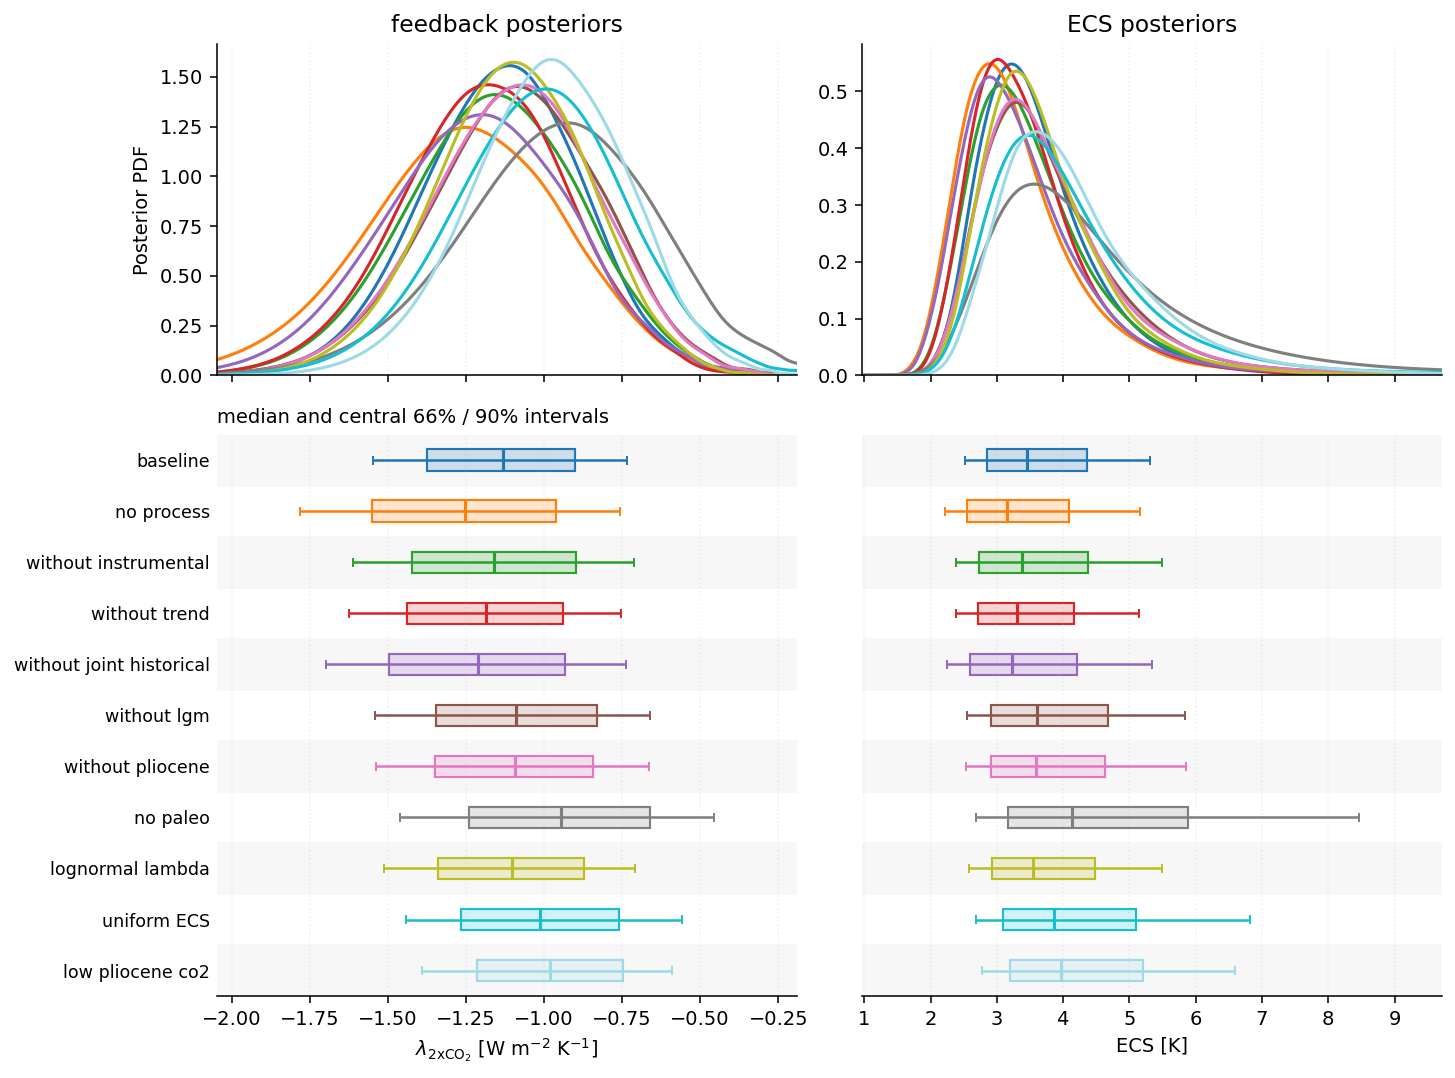

In [103]:
## rerun this cell after adding a case; every entry in results is included
all_case_smoothing = 1.75  ## larger values make the displayed PDFs smoother
all_case_limits = {"lamb": None, "ECS": None}  ## None uses automatic limits

if not results:
    print("Run at least one case with run_case(...) first.")
else:
    case_names = list(results)
    case_labels = [fill(str(name).replace("_", " "), width=27) for name in case_names]
    case_colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(case_names)))
    interval_height = max(1.8, 0.4 * len(case_names))
    fig, axes = plt.subplots(
        2, 2, figsize=(10.5, 3.4 + interval_height), sharex="col",
        gridspec_kw={"height_ratios": [2.6, interval_height]},
    )

    for col, (parameter, title, xlabel) in enumerate([
        ("lamb", "feedback posteriors", r"$\lambda_{\mathrm{2xCO_2}}$ [W m$^{-2}$ K$^{-1}$]"),
        ("ECS", "ECS posteriors", "ECS [K]"),
    ]):
        pdf_ax, interval_ax = axes[:, col]
        draws_by_case = [np.asarray(results[name][parameter]) for name in case_names]
        quantiles = np.array([
            np.quantile(draws, [.05, .17, .50, .83, .95])
            for draws in draws_by_case
        ])

        ## include every 90% interval, with extra space to show the PDF tails
        limits = all_case_limits[parameter]
        if limits is None:
            lo, hi = quantiles[:, 0].min(), quantiles[:, -1].max()
            padding = 0.2 * (hi - lo)
            limits = (lo - padding, min(0, hi + padding)) if parameter == "lamb" else (
                max(0, lo - padding), hi + padding
            )
        grid = np.linspace(*limits, 600)

        for row, (draws, color) in enumerate(zip(draws_by_case, case_colors)):
            ## smooth log(ECS) or log(-lambda), then convert back to a PDF
            ## dividing by the positive grid values accounts for the change of variable
            positive_draws = -draws if parameter == "lamb" else draws
            positive_grid = -grid if parameter == "lamb" else grid
            kde = gaussian_kde(
                np.log(positive_draws),
                bw_method=lambda kde: all_case_smoothing * kde.scotts_factor(),
            )
            density = np.zeros_like(grid)
            inside = positive_grid > 0
            density[inside] = kde(np.log(positive_grid[inside])) / positive_grid[inside]
            pdf_ax.plot(grid, density, color=color, lw=1.6)

            ## intervals always come from the raw samples, regardless of smoothing
            q05, q17, median, q83, q95 = quantiles[row]
            if row % 2 == 0:
                interval_ax.axhspan(row - .5, row + .5, color="0.97", zorder=0)
            interval_ax.hlines(row, q05, q95, color=color, lw=1.3)
            interval_ax.vlines([q05, q95], row - .09, row + .09, color=color, lw=1)
            interval_ax.add_patch(Rectangle(
                (q17, row - .21), q83 - q17, .42,
                facecolor=(*color[:3], .2), edgecolor=color, lw=1.1,
            ))
            interval_ax.vlines(median, row - .21, row + .21, color=color, lw=1.6)

        pdf_ax.set(title=title, ylim=(0, None))
        interval_ax.set(xlabel=xlabel, xlim=limits, ylim=(len(case_names) - .5, -.5))
        interval_ax.set_yticks(range(len(case_names)))
        interval_ax.set_yticklabels(case_labels if col == 0 else [])
        interval_ax.tick_params(axis="y", length=0, labelsize=9)
        interval_ax.spines["left"].set_visible(False)
        for ax in (pdf_ax, interval_ax):
            ax.spines[["top", "right"]].set_visible(False)
            ax.grid(axis="x", alpha=.2, ls=":")

    axes[0, 0].set_ylabel("Posterior PDF")
    axes[1, 0].set_title("median and central 66% / 90% intervals", loc="left", fontsize=10)
    finish_figure(fig, "fig_all_case_posteriors")


## posterior summaries

Compare the baseline and robustness tests.

In [38]:
## smoothing is only for displaying PDFs and estimating modes;
## this assessment's percentiles and means come directly from the Stan draws
def posterior_density(draws, grid, negative=False, bandwidth=0.12):
    positive = -draws if negative else draws
    x = -np.asarray(grid) if negative else np.asarray(grid)
    kde = gaussian_kde(np.log(positive), bw_method=bandwidth)
    return kde(np.log(x)) / x

def posterior_summary(draws, negative=False):
    positive = -draws if negative else draws
    grid = np.geomspace(*np.quantile(positive, [.001, .999]), 1_000)
    density = posterior_density(positive, grid, bandwidth=0.05)
    mode = grid[np.argmax(density)] * (-1 if negative else 1)
    return [*np.quantile(draws, [.05, .17, .50, .83, .95]), np.mean(draws), mode]

## SW20 archived ULI_MEDIUM_SAMPLE baseline, as in community_ecs
## 5th, 17th, 50th, 83rd, 95th percentiles, then mean and mode
## these are reference summaries for the plots and tables, not model inputs
sw20_ECS_summary = [2.255, 2.555, 3.105, 3.885, 4.695, 3.249, 2.955]
sw20_lambda_summary = [-1.785, -1.575, -1.295, -1.035, -0.855, -1.30183, -1.295]

plot_rows = [
    ("Baseline", "baseline", "navy"),
    ("Excl. Process", "no_process", "royalblue"),
    ("Excl. Instrumental", "without_instrumental", "darkorange"),
    ("Excl. Trend", "without_trend", "tab:red"),
    ("Excl. Joint Historical", "without_joint_historical", "orangered"),
    ("Excl. LGM", "without_lgm", "cornflowerblue"),
    ("Excl. Pliocene", "without_pliocene", "darkgreen"),
    ("Excl. Joint Paleo", "no_paleo", "mediumseagreen"),
    ("Lognormal Prior", "lognormal_lambda", "navy"),
    ("Uniform ECS Prior", "uniform_ECS", "navy"),
]
summary_rows = plot_rows + [("Pliocene CO2 = 250 ppm", "low_pliocene_co2", "gray")]
columns = ["5th", "17th", "50th", "83rd", "95th", "Mean", "Mode"]
ECS_summary = pd.DataFrame({label: posterior_summary(results[name]["ECS"])
    for label, name, _ in summary_rows}, index=columns).T
lambda_summary = pd.DataFrame({label: posterior_summary(results[name]["lamb"], negative=True)
    for label, name, _ in summary_rows}, index=columns).T
## put the SW20 reference at the bottom of each comparison
ECS_summary.loc["SW20 Baseline"] = sw20_ECS_summary
lambda_summary.loc["SW20 Baseline"] = sw20_lambda_summary
plot_rows.append(("SW20 Baseline", None, "gray"))

print("ECS [K]")
display(ECS_summary)
print("Feedback [W m-2 K-1]")
display(lambda_summary)
ECS_summary.to_csv(output_dir / "ECS_summary.csv")
lambda_summary.to_csv(output_dir / "lambda_summary.csv")

ECS [K]


,5th,17th,50th,83rd,95th,Mean,Mode
Baseline,2.522576,2.852783,3.456145,4.352785,5.315182,3.632262,3.280381
Excl. Process,2.217440,2.544792,3.151986,4.085130,5.155956,3.356429,2.882470
Excl. Instrumental,2.387062,2.730200,3.376864,4.372904,5.495859,3.593341,3.056858
Excl. Trend,2.383844,2.708222,3.307822,4.169364,5.150666,3.474141,3.064261
Excl. Joint Historical,2.254461,2.592244,3.221046,4.202767,5.334295,3.451068,2.849426
Excl. LGM,2.543769,2.909414,3.600934,4.683099,5.842608,3.847975,3.233996
Excl. Pliocene,2.540749,2.916087,3.596648,4.632242,5.850181,3.826811,3.205187
Excl. Joint Paleo,2.691199,3.171372,4.134495,5.891203,8.466861,4.887011,3.450933
Lognormal Prior,2.580647,2.921461,3.548148,4.483047,5.498856,3.736699,3.219384
Uniform ECS Prior,2.687933,3.087753,3.854546,5.105567,6.823316,4.670264,3.523359


Feedback [W m-2 K-1]


,5th,17th,50th,83rd,95th,Mean,Mode
Baseline,-1.548269,-1.374211,-1.133208,-0.899884,-0.735601,-1.136738,-1.069492
Excl. Process,-1.783583,-1.552690,-1.255145,-0.960784,-0.756171,-1.259177,-1.313601
Excl. Instrumental,-1.614110,-1.423795,-1.162236,-0.898675,-0.713528,-1.162205,-1.182529
Excl. Trend,-1.626803,-1.440489,-1.187882,-0.938649,-0.755088,-1.189599,-1.243244
Excl. Joint Historical,-1.699923,-1.497520,-1.212988,-0.933488,-0.738710,-1.215583,-1.195025
Excl. LGM,-1.541459,-1.346957,-1.090909,-0.831708,-0.662370,-1.091679,-1.105817
Excl. Pliocene,-1.538487,-1.350083,-1.092271,-0.842775,-0.665015,-1.096339,-1.088722
Excl. Joint Paleo,-1.462458,-1.240101,-0.947342,-0.662063,-0.456602,-0.951373,-0.930603
Lognormal Prior,-1.512982,-1.338792,-1.102922,-0.870873,-0.709092,-1.105505,-1.077665
Uniform ECS Prior,-1.442557,-1.265728,-1.012998,-0.759824,-0.558824,-1.008647,-1.013048


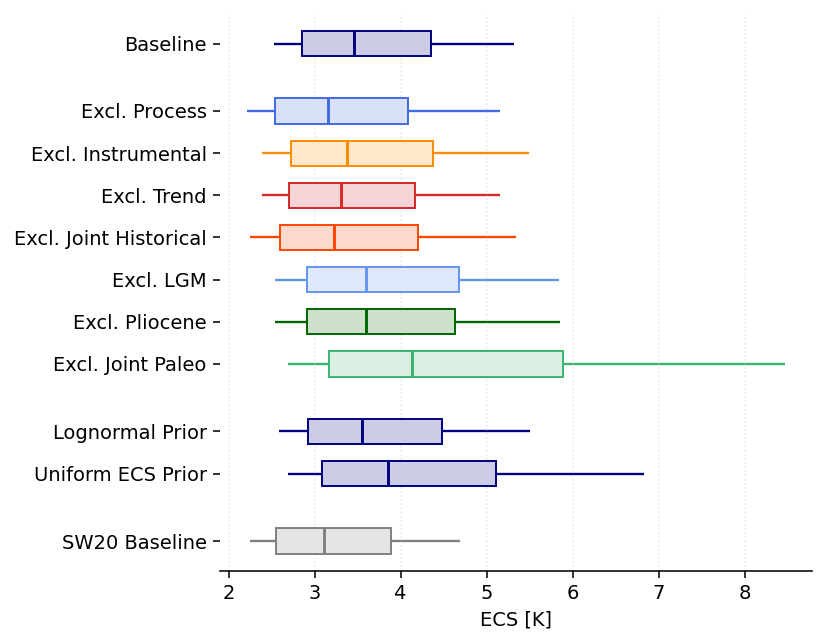

5–95% envelope for the selected tests representing the robust range: 2.383844015–5.850180924999999 K


In [104]:
## plot a subset of cases from the paper

fig, ax = plt.subplots(figsize=(6, 4.7))
positions, y = [], 0
for label, name, color in plot_rows:
    positions.append(y)
    q05, q17, median, q83, q95 = ECS_summary.loc[label, columns[:5]]
    ax.hlines(y, q05, q95, color=color, lw=1.2, zorder=1)
    ax.add_patch(Rectangle((q17, y-.3), q83-q17, .6, facecolor='w', alpha=1, zorder=2))
    ax.add_patch(Rectangle((q17, y-.3), q83-q17, .6, facecolor=color, alpha=.2, zorder=3))
    ax.add_patch(Rectangle((q17, y-.3), q83-q17, .6, fill=False, edgecolor=color, lw=1, zorder=3))
    ax.vlines(median, y-.3, y+.3, color=color, lw=1.5, zorder=3)
    y += 1.6 if label in ("Baseline", "Excl. Joint Paleo", "Uniform ECS Prior") else 1
ax.set(yticks=positions, yticklabels=[row[0] for row in plot_rows],
       ylim=(positions[-1]+.7, -.7), xlabel="ECS [K]")
ax.grid(axis="x", alpha=.3, ls=":")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.xticks(np.arange(2,8.1,1))
finish_figure(fig, "fig_sensitivity_tests")

robust_rows = ["Excl. Instrumental", "Excl. Trend", "Excl. LGM", "Excl. Pliocene", "Lognormal Prior"]
print("5–95% envelope for the selected tests representing the robust range:",
      f"{ECS_summary.loc[robust_rows, '5th'].min()}–{ECS_summary.loc[robust_rows, '95th'].max()} K")

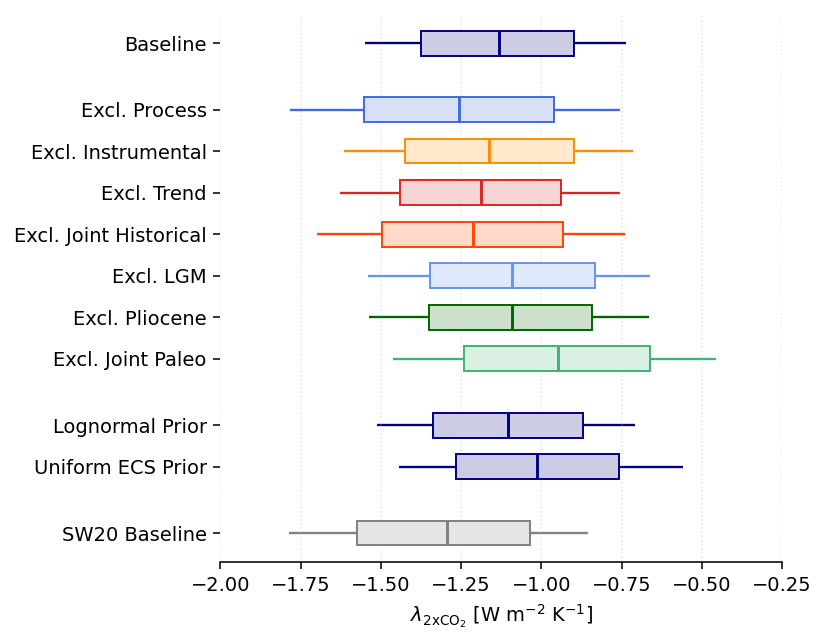

5–95% envelope for the selected tests representing the robust range: -1.626802565–-0.6623704825 W m-2 K-1


In [105]:
fig, ax = plt.subplots(figsize=(6, 4.7))
positions, y = [], 0
for label, name, color in plot_rows:
    positions.append(y)
    q05, q17, median, q83, q95 = lambda_summary.loc[label, columns[:5]]
    ax.hlines(y, q05, q95, color=color, lw=1.2, zorder=1)
    ax.add_patch(Rectangle((q17, y-.3), q83-q17, .6, facecolor='w', alpha=1, zorder=2))
    ax.add_patch(Rectangle((q17, y-.3), q83-q17, .6, facecolor=color, alpha=.2, zorder=3))
    ax.add_patch(Rectangle((q17, y-.3), q83-q17, .6, fill=False, edgecolor=color, lw=1, zorder=3))
    ax.vlines(median, y-.3, y+.3, color=color, lw=1.5, zorder=3)
    y += 1.6 if label in ("Baseline", "Excl. Joint Paleo", "Uniform ECS Prior") else 1
ax.set(yticks=positions, yticklabels=[row[0] for row in plot_rows],
       ylim=(positions[-1]+.7, -.7),
       xlabel=r"$\lambda_{\mathrm{2xCO_2}}$ [W m$^{-2}$ K$^{-1}$]")
ax.grid(axis="x", alpha=.3, ls=":")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_xticks(np.arange(-2.0, -0.19, 0.25))
finish_figure(fig, "fig_sensitivity_tests_lambda")

robust_rows = ["Excl. Instrumental", "Excl. Trend", "Excl. LGM", "Excl. Pliocene", "Lognormal Prior"]
print("5–95% envelope for the selected tests representing the robust range:",
      f"{lambda_summary.loc[robust_rows, '5th'].min()}–"
      f"{lambda_summary.loc[robust_rows, '95th'].max()} W m-2 K-1")

# Likelihoods (optional)

Stan already combines the evidence above into a posterior, so we do not need to calculate separate likelihoods. These separate calculations simply help illustrate each line of evidence. We use the **assessed input distributions**, not the posterior samples from Stan, and we do not apply a prior on the total feedback in these likelihood calculations.

For each proposed feedback, the historical and paleo calculations follow the same steps:

1. Draw all uncertain forcing terms and pattern effects from their assessed distributions. The paleo calculations also draw the LGM CO$_2$ forcing ratio, Pliocene CO$_2$ concentration, and other-GHG contribution.
2. Calculate the mean energy imbalance for each draw: $\bar N = F + (\lambda-\Delta\lambda)\mu_T$.
3. Combine the independent energy-imbalance and temperature uncertainties: $V_N = \sigma_N^2 + (\lambda-\Delta\lambda)^2\sigma_T^2$. Note that the calculations can be accelerated if the forcing uncertainty is analytically integrated rather than sampled via Monte Carlo.
4. Evaluate `norm.pdf(mu_N, loc=N_mean, scale=np.sqrt(variance_N))`. This compares the assessed imbalance with the predicted mean, allowing for the combined uncertainty.
5. Average those density values over the uncertainty draws to obtain the likelihood at this feedback.

This procedure estimates the following marginal likelihood for an individual historical/paleo line of evidence:

$$
\mathcal{L}(\lambda_\mathrm{2xCO_2})
=
\iiint
\mathcal{N}\!\left(\mu_N \mid F + (\lambda_\mathrm{2xCO_2}-\Delta\lambda)T,\;\sigma_N^2\right)
\,p(F)\,p(T)\,p(\Delta\lambda)
\,\mathrm{d}F\,\mathrm{d}T\,\mathrm{d}\Delta\lambda.
$$

Temperature uncertainty is included analytically in step 3, rather than sampled, to reduce Monte Carlo noise. All forcing uncertainty is represented by the draws, so no forcing variance is added again in step 3. Keep the full normal density, including its normalization: the variance changes with feedback.

Both the **joint historical** and **joint paleo** likelihoods multiply the two periods' densities for each matched draw, then average. Historical aerosol and other-forcing terms are drawn in correlated pairs. Matching the draws retains these forcing covariances, the common CO$_2$ forcing, and the correlated paleo pattern effects. Multiplying the separately averaged likelihoods would lose those dependencies.

For the ECS curves, we hold ECS fixed and substitute $\lambda=-F_{\mathrm{2xCO_2}}/\mathrm{ECS}$ for each forcing draw, then repeat exactly the same energy-budget calculation. There is no density-transformation factor in these likelihoods. That factor is needed later when converting a posterior PDF between feedback and ECS.

The code below writes out each period's forcing, energy budget, uncertainty, and averaging step. The outer function lets us repeat the same calculation for revised inputs. The same random draws are reused at all grid points to reduce noise between neighboring points. Finally, each curve is divided by its own maximum for plotting; this does not turn it into a posterior PDF.


In [106]:
individual_evidence = ("Process", "Instrumental", "Trend", "LGM", "Pliocene")
evidence_colors = {
    "Process": "#4b57db", "Instrumental": "darkorange", "Trend": "tab:red",
    "Joint Historical": "orangered", "LGM": "cornflowerblue",
    "Pliocene": "darkgreen", "Joint Paleo": "mediumseagreen",
}


def calculate_likelihoods(data, settings=None):
    ## keep the calculation in one function so we can repeat it with revised inputs
    ## data contains the assessed inputs, not samples from the Stan posterior
    validate_inputs(data)
    data = dict(data)
    settings = {**likelihood_settings, **(settings or {})}
    number_of_draws = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    ############################################################
    ## 1. draw the uncertainties that we average over numerically
    ############################################################
    ## use the same draws at every grid point to reduce noise between nearby points
    ## every period shares the same CO2-doubling forcing in a given draw
    F_2xCO2_draws = truncnorm.rvs(
        (1e-6 - data["erf_2x"]) / data["sig_F2xCO2"], np.inf,
        loc=data["erf_2x"], scale=data["sig_F2xCO2"],
        size=number_of_draws, random_state=rng,
    )

    ## historical pattern effects: skew-normal for instrumental, normal for trend
    dlambda_instrumental_draws = skewnorm.rvs(
        data["shape_dlambda_instrumental"],
        loc=data["loc_dlambda_instrumental"],
        scale=data["scale_dlambda_instrumental"],
        size=number_of_draws, random_state=rng,
    )
    dlambda_trend_draws = rng.normal(
        data["mu_dlambda_trend"], data["sig_dlambda_trend"], number_of_draws,
    )

    ## draw the paleo pattern effects together to retain their assessed correlation
    covariance_dlambda_paleo = (
        data["rho_dlambda_LGM_plio"]
        * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"]
    )
    paleo_pattern_draws = rng.multivariate_normal(
        [data["mu_dlambda_LGM"], data["mu_dlambda_plio"]],
        [[data["sig_dlambda_LGM"]**2, covariance_dlambda_paleo],
         [covariance_dlambda_paleo, data["sig_dlambda_plio"]**2]],
        size=number_of_draws,
    )
    dlambda_LGM_draws = paleo_pattern_draws[:, 0]
    dlambda_plio_draws = paleo_pattern_draws[:, 1]

    ## LGM CO2 forcing is an uncertain fraction of the CO2-doubling forcing
    f_CO2_LGM_draws = rng.normal(
        data["mu_f_CO2_LGM"], data["sig_f_CO2_LGM"], number_of_draws,
    )

    ## Pliocene CO2 concentrations must be positive
    CO2_plio_draws = truncnorm.rvs(
        -data["mu_CO2_plio"] / data["sig_CO2_plio"], np.inf,
        loc=data["mu_CO2_plio"], scale=data["sig_CO2_plio"],
        size=number_of_draws, random_state=rng,
    )
    f_otherGHG_draws = rng.normal(
        data["mu_f_otherGHG"], data["sig_f_otherGHG"], number_of_draws,
    )
    ## convert each concentration to forcing relative to a preindustrial CO2 doubling
    f_CO2_plio_draws = (
        (co2_sarf(CO2_plio_draws) - co2_sarf(data["CO2_PI"]))
        / (co2_sarf(2 * data["CO2_PI"]) - co2_sarf(data["CO2_PI"]))
    )

    ## draw historical aerosol forcing in pairs to retain its cross-period covariance
    aerosol_forcing_draws = rng.multivariate_normal(
        [data["mu_F_anthro_aerosol_instrumental"], data["mu_F_anthro_aerosol_trend"]],
        [[data["sig_F_anthro_aerosol_instrumental"]**2,
          data["cov_F_anthro_aerosol_instrumental_trend"]],
         [data["cov_F_anthro_aerosol_instrumental_trend"],
          data["sig_F_anthro_aerosol_trend"]**2]],
        size=number_of_draws,
    )
    F_aerosol_instrumental_draws = aerosol_forcing_draws[:, 0]
    F_aerosol_trend_draws = aerosol_forcing_draws[:, 1]

    ## the other historical forcing terms have their own cross-period covariance
    other_forcing_draws = rng.multivariate_normal(
        [data["mu_F_other_instrumental"], data["mu_F_other_trend"]],
        [[data["sig_F_other_instrumental"]**2,
          data["cov_F_other_instrumental_trend"]],
         [data["cov_F_other_instrumental_trend"],
          data["sig_F_other_trend"]**2]],
        size=number_of_draws,
    )
    F_other_instrumental_draws = other_forcing_draws[:, 0]
    F_other_trend_draws = other_forcing_draws[:, 1]

    ## draw the remaining paleo forcing terms from their assessed distributions
    F_other_LGM_draws = rng.normal(
        data["mu_F_other_LGM"], data["sig_F_other_LGM"], number_of_draws,
    )
    F_plio_nonGHG_draws = rng.normal(
        data["mu_F_plio_nonGHG"], data["sig_F_plio_nonGHG"], number_of_draws,
    )

    ## temperature uncertainty is still included analytically in each N variance below

    ##############################################
    ## 2. choose the feedback and ECS values to try
    ##############################################
    grids = {
        "lambda": np.linspace(-4, -0.005, settings["grid_points"]),
        "ECS": np.linspace(0.01, 10, settings["grid_points"]),
    }

    ## each line of evidence gets one likelihood array for each horizontal axis
    raw = {}
    for evidence in evidence_colors:
        raw[evidence] = {
            "lambda": np.zeros(len(grids["lambda"])),
            "ECS": np.zeros(len(grids["ECS"])),
        }

    for parameter, grid in grids.items():
        for i, proposed_value in enumerate(grid):
            if parameter == "lambda":
                ## the same proposed feedback applies to every uncertainty draw
                lamb = proposed_value
            else:
                ## hold ECS fixed; each forcing draw implies its own feedback
                lamb = -F_2xCO2_draws / proposed_value

            ####################
            ## process evidence
            ####################
            ## compare the proposed feedback with the assessed process distribution
            ## in ECS space, average over the CO2-doubling forcing uncertainty
            process_likelihood = norm.pdf(
                lamb, loc=data["mu_lambda"], scale=data["sig_lambda"],
            )
            raw["Process"][parameter][i] = np.mean(process_likelihood)

            ###################
            ## instrumental era
            ###################
            ## total forcing for each draw: CO2 + aerosols + other forcing
            F_instrumental_draws = (
                data["f_CO2_instrumental"] * F_2xCO2_draws
                + F_aerosol_instrumental_draws + F_other_instrumental_draws
            )

            ## N = F + (lambda - dlambda) * T
            feedback_instrumental = lamb - dlambda_instrumental_draws
            N_instrumental_mean = (
                F_instrumental_draws + feedback_instrumental * data["mu_T_instrumental"]
            )
            ## independent N error + temperature error; forcing uncertainty is sampled
            ## a temperature error contributes feedback * temperature error to N
            variance_N_instrumental = (
                data["sig_N_instrumental"]**2
                + feedback_instrumental**2 * data["sig_T_instrumental"]**2
            )

            ## density of the assessed N given each predicted mean and combined uncertainty
            instrumental_likelihood = norm.pdf(
                data["mu_N_instrumental"], loc=N_instrumental_mean,
                scale=np.sqrt(variance_N_instrumental),
            )
            ## average over the forcing and pattern-effect draws
            raw["Instrumental"][parameter][i] = instrumental_likelihood.mean()

            #######################
            ## 21st-century trends
            #######################
            ## same energy budget; T, N, and forcing changes are all per decade
            F_trend_draws = (
                data["f_CO2_trend"] * F_2xCO2_draws
                + F_aerosol_trend_draws + F_other_trend_draws
            )
            feedback_trend = lamb - dlambda_trend_draws
            N_trend_mean = F_trend_draws + feedback_trend * data["mu_T_trend"]
            variance_N_trend = (
                data["sig_N_trend"]**2
                + feedback_trend**2 * data["sig_T_trend"]**2
            )
            trend_likelihood = norm.pdf(
                data["mu_N_trend"], loc=N_trend_mean, scale=np.sqrt(variance_N_trend),
            )
            raw["Trend"][parameter][i] = trend_likelihood.mean()

            ############################
            ## joint historical evidence
            ############################
            ## multiply the two densities for each matched draw, then average
            ## the paired forcing draws above retain their cross-period covariances
            ## both periods also use the same CO2-doubling forcing in each draw
            historical_likelihood = instrumental_likelihood * trend_likelihood
            raw["Joint Historical"][parameter][i] = historical_likelihood.mean()

            ######
            ## LGM
            ######
            ## CO2 + other forcing; the CO2 ratio and doubling forcing are both sampled
            F_LGM_draws = f_CO2_LGM_draws * F_2xCO2_draws + F_other_LGM_draws
            feedback_LGM = lamb - dlambda_LGM_draws
            N_LGM_mean = F_LGM_draws + feedback_LGM * data["mu_T_LGM"]
            variance_N_LGM = (
                data["sig_N_LGM"]**2
                + feedback_LGM**2 * data["sig_T_LGM"]**2
            )
            LGM_likelihood = norm.pdf(
                data["mu_N_LGM"], loc=N_LGM_mean, scale=np.sqrt(variance_N_LGM),
            )
            raw["LGM"][parameter][i] = LGM_likelihood.mean()

            ###########
            ## Pliocene
            ###########
            ## total GHG forcing = CO2 forcing * (1 + other-GHG / CO2 forcing)
            F_CO2_plio = f_CO2_plio_draws * F_2xCO2_draws
            F_plio_draws = (
                F_CO2_plio * (1 + f_otherGHG_draws) + F_plio_nonGHG_draws
            )
            feedback_plio = lamb - dlambda_plio_draws
            N_plio_mean = F_plio_draws + feedback_plio * data["mu_T_plio"]
            variance_N_plio = (
                data["sig_N_plio"]**2
                + feedback_plio**2 * data["sig_T_plio"]**2
            )
            plio_likelihood = norm.pdf(
                data["mu_N_plio"], loc=N_plio_mean, scale=np.sqrt(variance_N_plio),
            )
            raw["Pliocene"][parameter][i] = plio_likelihood.mean()

            #######################
            ## joint paleo evidence
            #######################
            ## multiply the LGM and Pliocene densities for each matched uncertainty draw
            ## then average: this retains the shared F_2xCO2 and correlated pattern effects
            ## multiplying their separate means would lose these shared uncertainties
            paleo_likelihood = LGM_likelihood * plio_likelihood
            raw["Joint Paleo"][parameter][i] = paleo_likelihood.mean()

    #################################################
    ## 3. scale each curve to a maximum of 1 for plots
    #################################################
    ## keep the unscaled values in raw as well; no feedback prior is applied here
    curves = {}
    for evidence in raw:
        curves[evidence] = {}
        for parameter in grids:
            likelihood_values = raw[evidence][parameter]
            curves[evidence][parameter] = likelihood_values / likelihood_values.max()

    return {"data": data, "settings": settings, "grids": grids,
            "raw": raw, "curves": curves}


### run the likelihood calc or adapt it to another line of evidence

The cell below uses the inputs saved with the baseline run. To explore revised inputs, pass a revised dictionary to `calculate_likelihoods`; the lower-CO$_2$ Pliocene example below uses the same function.

For another energy-budget constraint, use the instrumental or LGM block as a template: write its forcing sum, its period-specific feedback, its predicted imbalance, and each term in its residual variance. Draw its uncertain forcings and pattern effects, retain the analytic temperature uncertainty, evaluate the normal density, and average. Add the new line's name to `evidence_colors` and store its curve in `raw` in the same way. The independent-error variance formula needs covariance terms if the new evidence has correlated errors. For a joint likelihood, retain shared uncertainties in matched draws and average the product of the densities. For non-Gaussian errors or a nonlinear energy budget, sample those uncertain terms explicitly rather than applying the Gaussian variance formula.


In [108]:
%%time
## calculate each likelihood using the assessed inputs from the baseline run
likelihoods = calculate_likelihoods(baseline["data"])

## tabulate the grid point at which each relative likelihood is largest
peak_rows = []
for evidence in evidence_colors:
    feedback_likelihood = likelihoods["curves"][evidence]["lambda"]
    ECS_likelihood = likelihoods["curves"][evidence]["ECS"]
    feedback_at_peak = likelihoods["grids"]["lambda"][np.argmax(feedback_likelihood)]
    ECS_at_peak = likelihoods["grids"]["ECS"][np.argmax(ECS_likelihood)]
    peak_rows.append({
        "evidence": evidence,
        "feedback at peak (W m-2 K-1)": feedback_at_peak,
        "ECS at peak (K)": ECS_at_peak,
    })
likelihood_peak_table = pd.DataFrame(peak_rows).set_index("evidence")
display(likelihood_peak_table)
likelihood_peak_table.to_csv(output_dir / "likelihood_peaks.csv")

## save the horizontal-axis values and relative likelihoods used in the plots
for parameter in ("lambda", "ECS"):
    likelihood_table = pd.DataFrame({parameter: likelihoods["grids"][parameter]})
    for evidence in evidence_colors:
        likelihood_table[evidence] = likelihoods["curves"][evidence][parameter]
    likelihood_table.to_csv(output_dir / f"likelihoods_{parameter}.csv", index=False)


,feedback at peak (W m-2 K-1),ECS at peak (K)
evidence,,
Process,-0.925691,4.274269
Instrumental,-1.069800,3.673667
Trend,-0.701523,5.555551
Joint Historical,-0.957715,4.114108
LGM,-1.462094,2.692685
Pliocene,-1.486112,2.632625
Joint Paleo,-1.470100,2.672665


### Process posterior and prior comparison

- Now we can calculate process-only distributions by integration, without another sampling run. We use the same feedback bounds and priors as Stan and retain uncertainty in $F_{\mathrm{2xCO_2}}$.
- When converting a lambda PDF to an ECS PDF, the factor $F_{\mathrm{2xCO_2}}/\mathrm{ECS}^2$ accounts for the change of variable.
- Plots show only 0–10 K but they are not renormalized to that interval (ie they retain the prior bounds for lambda set atop the notebook).

In [109]:
def prior_pdf_lambda(values, data, prior):
    x = np.asarray(values)
    lo, hi = data["lambda_lower"], data["lambda_upper"]
    if prior == "uniform_lambda":
        pdf = np.ones_like(x) / (hi-lo)
    elif prior == "uniform_ECS":
        pdf = 1 / (x*x*(-1/hi + 1/lo))
    elif prior == "lognormal_lambda":
        distribution = lognorm(s=data["lognormal_sigma"], scale=np.exp(data["lognormal_mu"]))
        pdf = distribution.pdf(-x) / (distribution.cdf(-lo)-distribution.cdf(-hi))
    else:
        raise ValueError(f"Unknown prior: {prior}")
    return np.where((x >= lo) & (x <= hi), pdf, 0)

def process_distributions(data, grids, prior):
    ## integrate over the full feedback support, including the long ECS tail
    full_grid = -np.geomspace(-data["lambda_lower"], -data["lambda_upper"], 30_000)
    likelihood = lambda x: norm.pdf(x, data["mu_lambda"], data["sig_lambda"])
    normalization = trapezoid(prior_pdf_lambda(full_grid, data, prior)*likelihood(full_grid), full_grid)
    mu, sig = data["erf_2x"], data["sig_F2xCO2"]
    F = np.linspace(max(1e-6, mu-8*sig), mu+8*sig, 512)
    F_pdf = truncnorm.pdf(F, (1e-6-mu)/sig, np.inf, loc=mu, scale=sig)
    ECS = grids["ECS"][:, None]
    lambda_at_ECS = -F[None, :] / ECS
    prior_at_ECS = prior_pdf_lambda(lambda_at_ECS, data, prior)
    transform = F_pdf[None, :] * F[None, :] / ECS**2
    return {
        "prior": {
            "lambda": prior_pdf_lambda(grids["lambda"], data, prior),
            "ECS": trapezoid(prior_at_ECS*transform, F, axis=1),
        },
        "posterior": {
            "lambda": prior_pdf_lambda(grids["lambda"], data, prior)*likelihood(grids["lambda"])/normalization,
            "ECS": trapezoid(prior_at_ECS*likelihood(lambda_at_ECS)*transform, F, axis=1)/normalization,
        },
    }

process_pdfs = {prior: process_distributions(baseline["data"], likelihoods["grids"], prior)
                for prior in ("uniform_lambda", "lognormal_lambda", "uniform_ECS")}
process_posterior = process_pdfs["uniform_lambda"]["posterior"]

## likelihood and synthesis figures


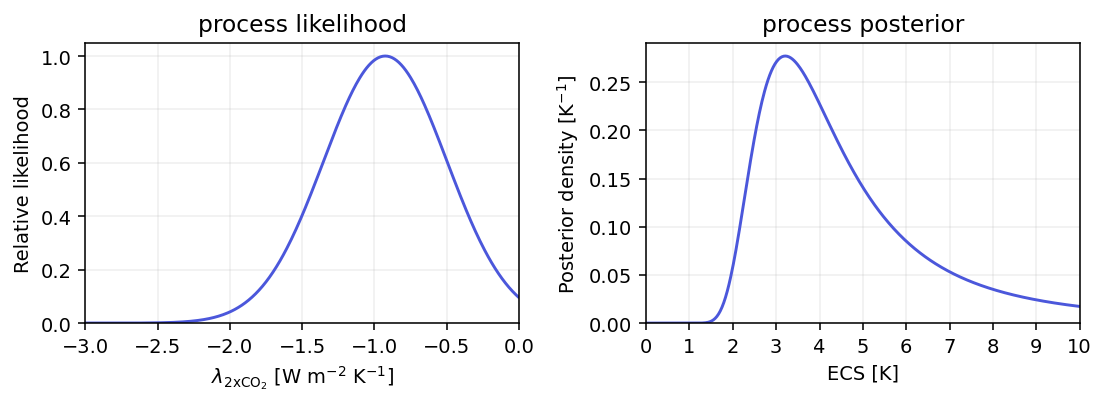

In [110]:
feedback_label = r"$\lambda_{\mathrm{2xCO_2}}$ [W m$^{-2}$ K$^{-1}$]"

def format_pair(axes):
    for ax, xlabel, limits, ticks in zip(axes,
            [feedback_label, "ECS [K]"], [(-3, 0), (0, 10)],
            [np.arange(-3, 0.01, 0.5), np.arange(0, 11)]):
        ax.set(xlabel=xlabel, xlim=limits, xticks=ticks)
        ax.grid(alpha=0.2)

def plot_likelihoods(result, evidence, name):
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    for ax, parameter in zip(axes, ("lambda", "ECS")):
        for line in evidence:
            ax.plot(result["grids"][parameter], result["curves"][line][parameter],
                    color=evidence_colors[line], label=line, lw=1.5)
        ax.set(ylim=(0, 1.05), title="radiative feedback" if parameter == "lambda" else "ECS")
    axes[0].set_ylabel("Relative likelihood")
    axes[0].legend(frameon=False, fontsize=9)
    format_pair(axes)
    finish_figure(fig, name)

## process: feedback likelihood on the left, ECS posterior density on the right
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(likelihoods["grids"]["lambda"], likelihoods["curves"]["Process"]["lambda"], color=evidence_colors["Process"])
axes[1].plot(likelihoods["grids"]["ECS"], process_posterior["ECS"], color=evidence_colors["Process"])
axes[0].set(ylabel="Relative likelihood", title="process likelihood", ylim=(0, 1.05))
axes[1].set(ylabel=r"Posterior density [K$^{-1}$]", title="process posterior", ylim=(0, None))
format_pair(axes)
finish_figure(fig, "fig_process_likely")

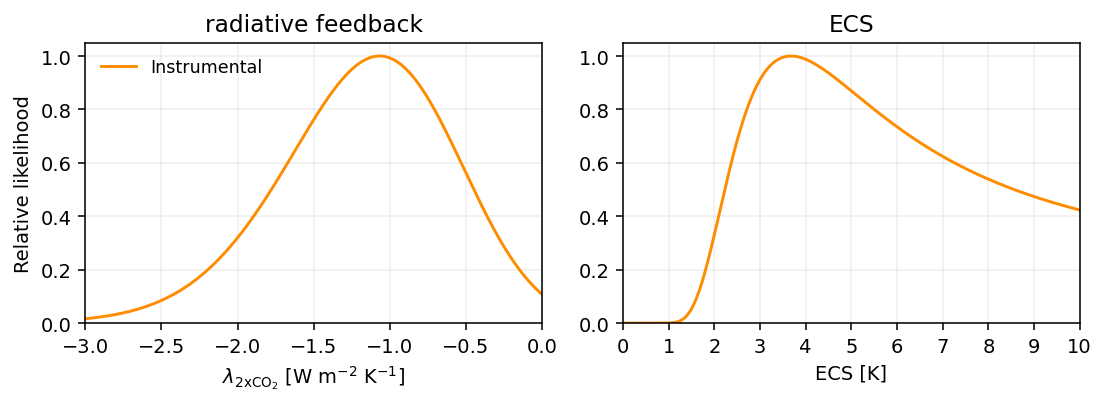

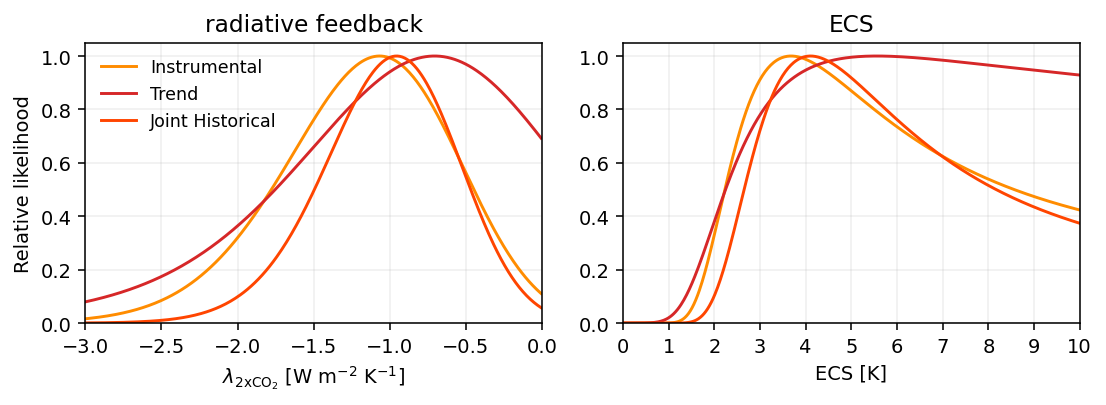

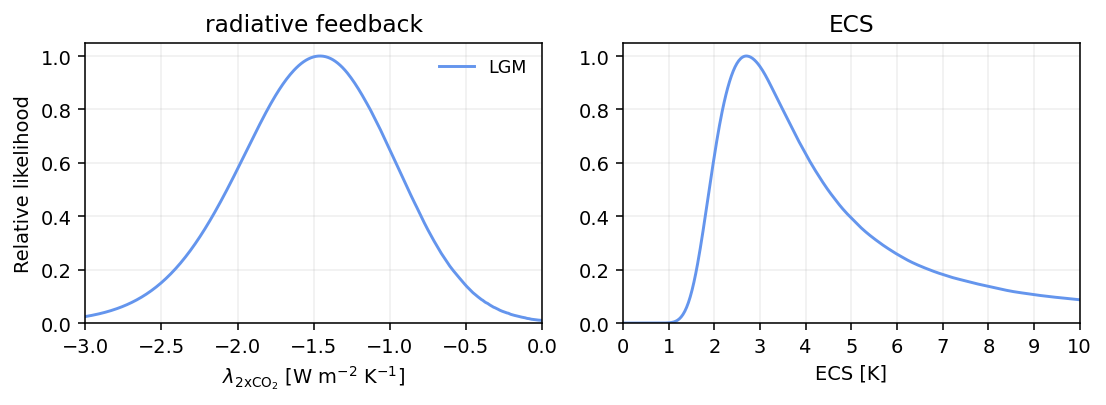

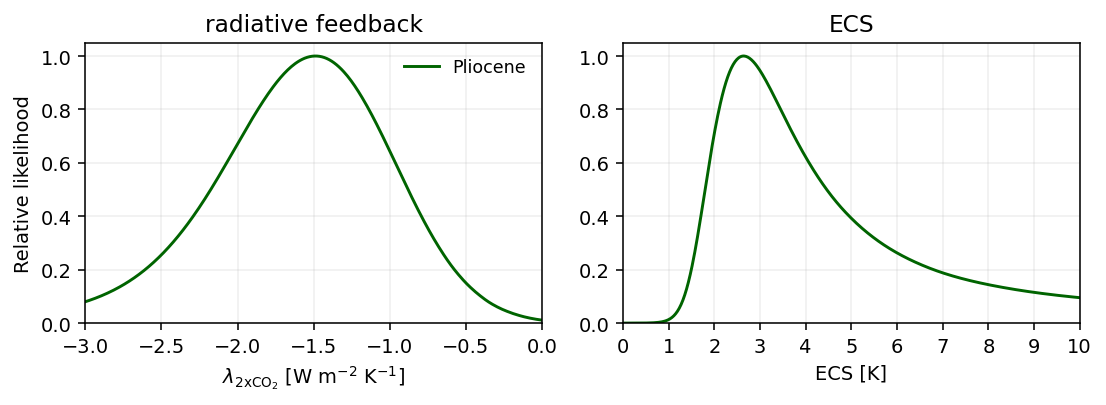

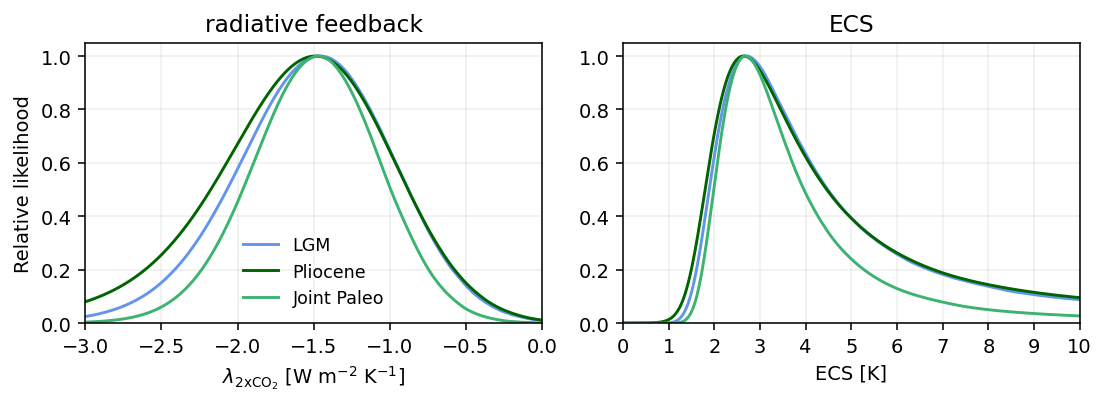

In [111]:
plot_likelihoods(likelihoods, ["Instrumental"], "fig_inst_likely")
plot_likelihoods(likelihoods, ["Instrumental", "Trend", "Joint Historical"], "fig_joint_hist")
plot_likelihoods(likelihoods, ["LGM"], "fig_lgm_likely")
plot_likelihoods(likelihoods, ["Pliocene"], "fig_plio_likely")
plot_likelihoods(likelihoods, ["LGM", "Pliocene", "Joint Paleo"], "fig_joint_paleo")

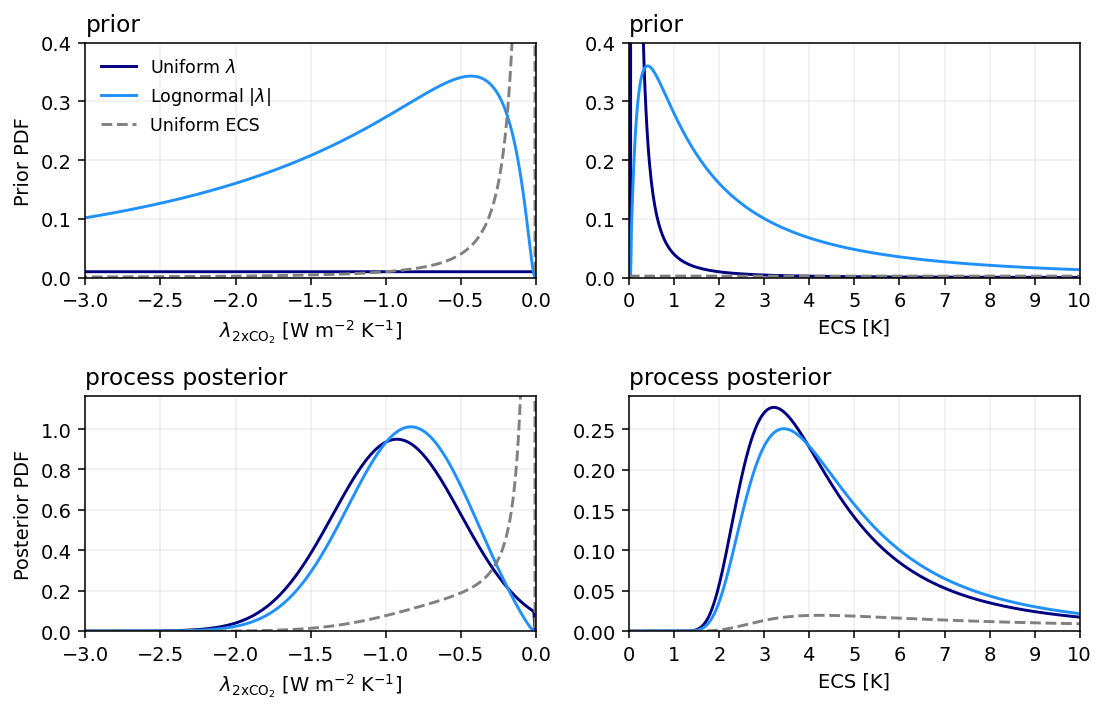

In [112]:
## illustrate priors and the process posteriors after combing with process lamdba 
prior_labels = {"uniform_lambda": r"Uniform $\lambda$",
                "lognormal_lambda": r"Lognormal $|\lambda|$", "uniform_ECS": "Uniform ECS"}
prior_colors = {"uniform_lambda": "navy", "lognormal_lambda": "dodgerblue", "uniform_ECS": "gray"}

fig, axes = plt.subplots(2, 2, figsize=(8, 5.2))
for row, kind in enumerate(("prior", "posterior")):
    for col, parameter in enumerate(("lambda", "ECS")):
        for prior, values in process_pdfs.items():
            axes[row, col].plot(likelihoods["grids"][parameter], values[kind][parameter],
                label=prior_labels[prior], color=prior_colors[prior],
                ls="--" if prior == "uniform_ECS" else "-")
        title = "prior" if row == 0 else "process posterior"
        axes[row, col].set_title(title, loc="left")
        axes[row, col].set_ylim(bottom=0)
    axes[row, 0].set_ylabel("Prior PDF" if row == 0 else "Posterior PDF")
    format_pair(axes[row])
axes[0, 0].legend(frameon=False, fontsize=9)

## zoom in on the main curves, as in the paper; all PDFs keep their full normalization
for ax in axes[0]:
    ax.set_ylim(0, 0.4)
axes[1, 0].set_ylim(0, 1.15 * max(
    process_pdfs[p]["posterior"]["lambda"].max()
    for p in ("uniform_lambda", "lognormal_lambda")))
finish_figure(fig, "fig_prior_process_comparison")

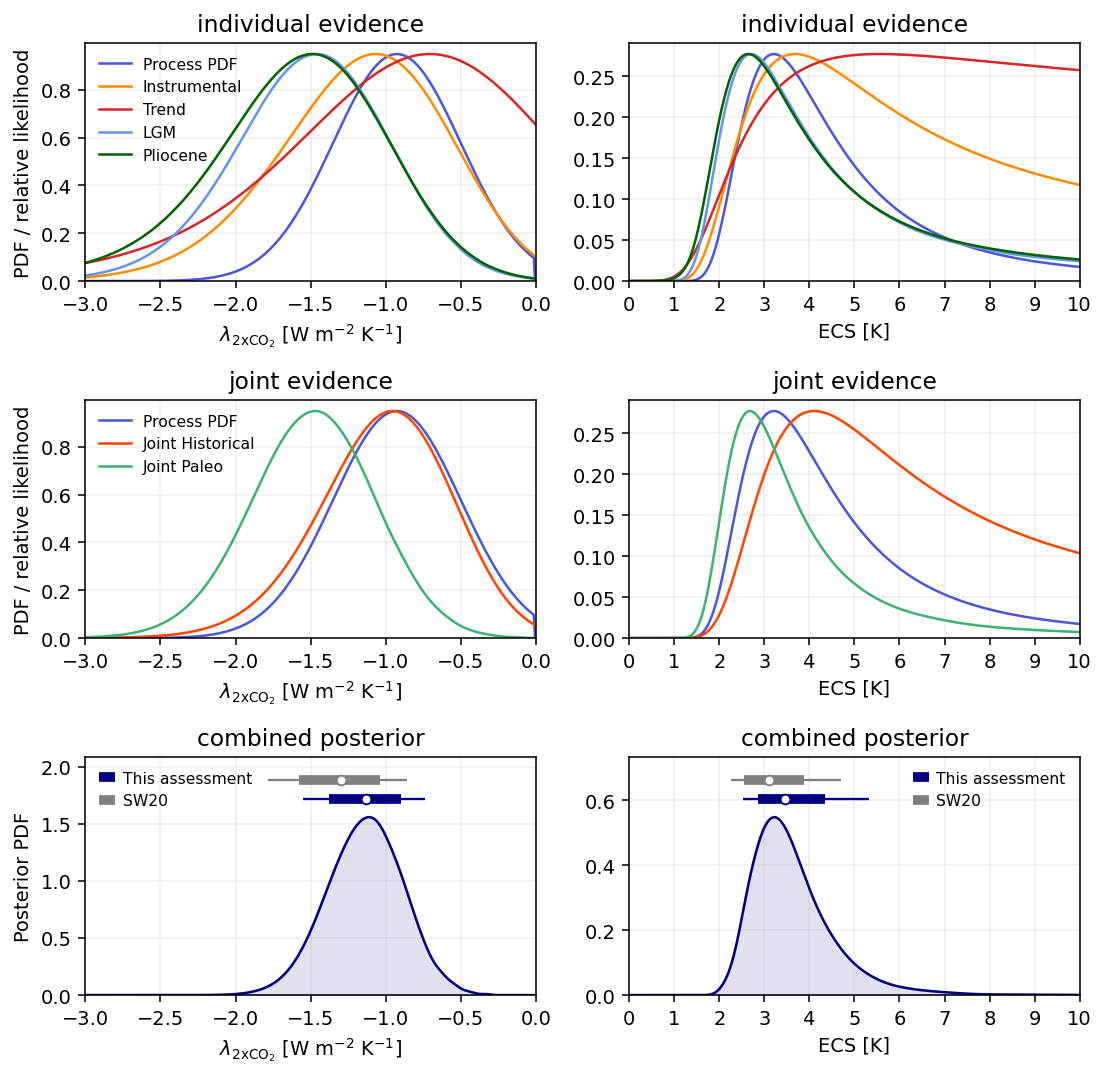

In [113]:
## smoothing of posterior density, relative to automatic bandwidth
## larger values give smoother PDFs; medians and intervals still use the raw draws
pdf_smoothing = 1.75

fig, axes = plt.subplots(3, 2, figsize=(8, 7.8))
for row, evidence in enumerate((individual_evidence, ("Process", "Joint Historical", "Joint Paleo"))):
    for col, parameter in enumerate(("lambda", "ECS")):
        ax = axes[row, col]
        for name in evidence:
            y = process_posterior[parameter] if name == "Process" else (
                likelihoods["curves"][name][parameter] * process_posterior[parameter].max())
            ax.plot(likelihoods["grids"][parameter], y, color=evidence_colors[name],
                    label="Process PDF" if name == "Process" else name, lw=1.3)
        ax.set_ylim(bottom=0)
        title = "individual evidence" if row == 0 else "joint evidence"
        ax.set_title(title, loc="center")
    axes[row, 0].set_ylabel("PDF / relative likelihood")
    axes[row, 0].legend(frameon=False, fontsize=8)

## the combined posterior comes from Stan and retains all shared uncertainties
for col, (parameter, draw_name) in enumerate((("lambda", "lamb"), ("ECS", "ECS"))):
    ax = axes[2, col]
    grid, draws = likelihoods["grids"][parameter], baseline[draw_name]
    density = posterior_density(
        draws, grid, negative=(parameter == "lambda"),
        bandwidth=lambda kde: pdf_smoothing * kde.scotts_factor(),
    )
    ax.plot(grid, density, color="navy", lw=1.3)
    ax.fill_between(grid, density, color="navy", alpha=0.12)
    q05, q17, median, q83, q95 = np.quantile(draws, [.05, .17, .5, .83, .95])
    y = density.max()*1.10
    ax.hlines(y, q05, q95, color="navy", lw=1.2)
    ax.hlines(y, q17, q83, color="navy", lw=5, label="This assessment")
    ax.plot(median, y, "o", mfc="white", mec="navy", ms=5)
    ## archived SW20 intervals above this assessment; the PDF is ours
    sw20 = sw20_lambda_summary if parameter == "lambda" else sw20_ECS_summary
    sw05, sw17, sw50, sw83, sw95 = sw20[:5]
    sw20_y = density.max()*1.21
    ax.hlines(sw20_y, sw05, sw95, color="gray", lw=1.2)
    ax.hlines(sw20_y, sw17, sw83, color="gray", lw=5, label="SW20")
    ax.plot(sw50, sw20_y, "o", mfc="white", mec="gray", ms=5)
    ax.set(ylim=(0, density.max()*1.34), title="combined posterior")
    ax.legend(frameon=False, fontsize=8, handlelength=1, handletextpad=0.5,
              loc="upper left" if parameter == "lambda" else "upper right")
axes[2, 0].set_ylabel("Posterior PDF")
for row in axes:
    format_pair(row)
finish_figure(fig, "fig_combined_likelihoods")

In the synthesis figure, process curves are PDFs while the other relative likelihoods are scaled to the process PDF's peak for display. The combined-posterior bars mark the median and central 66% and 90% intervals. Gray intervals show the SW20 baseline for comparison.

The posterior PDF in the plot above is a smoothed estimate of the sampled distribution (note that smoothing is only for plotting purposes). `pdf_smoothing` controls the smoothing for this figure; increasing it reduces small deviations for plotting purposes. The median and interval endpoints are calculated directly from the samples and dont change with this setting. `iter_sampling` can also be increased to produce a smoother PDF.

Deviations from a smooth PDF can remain even when the posterior ranges are well constrained by the sample size because PDF density is only the local shape, whereas percentiles depend on accumulated probability. Evaluate whether sampling precision is sufficient based on R-hat and tail ESS rather than the smoothness of the PDF. Increase sampling if those errors are too large and if a smoother PDF is desired. Also see the [Stan diagnostic guidance](https://mc-stan.org/learn-stan/diagnostics-warnings.html).
